In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 6311629) PSD_funcs: (3, 3155814)
[TRUE] SNR: 44.679967
[TRUE] SNR - Channel 0: 31.680252
[TRUE] SNR - Channel 1: 31.413214
[TRUE] SNR - Channel 2: 2.423038
[INFO] Frequency resolution delta_f: 3.168754e-08 Hz, Number of frequency bins: 3155815
freq_max: 0.100000 Hz and Freq_min: 0.000000 Hz


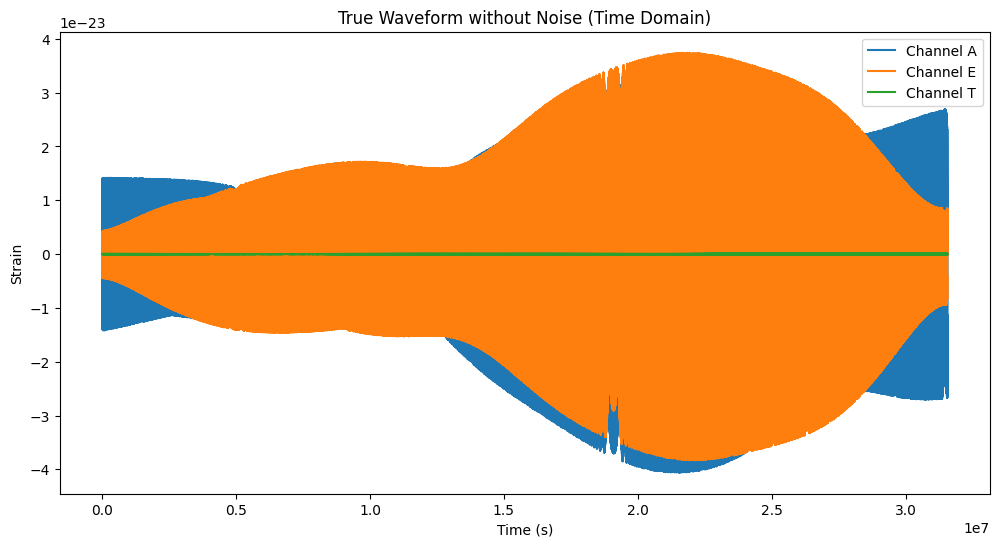

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 3155814)


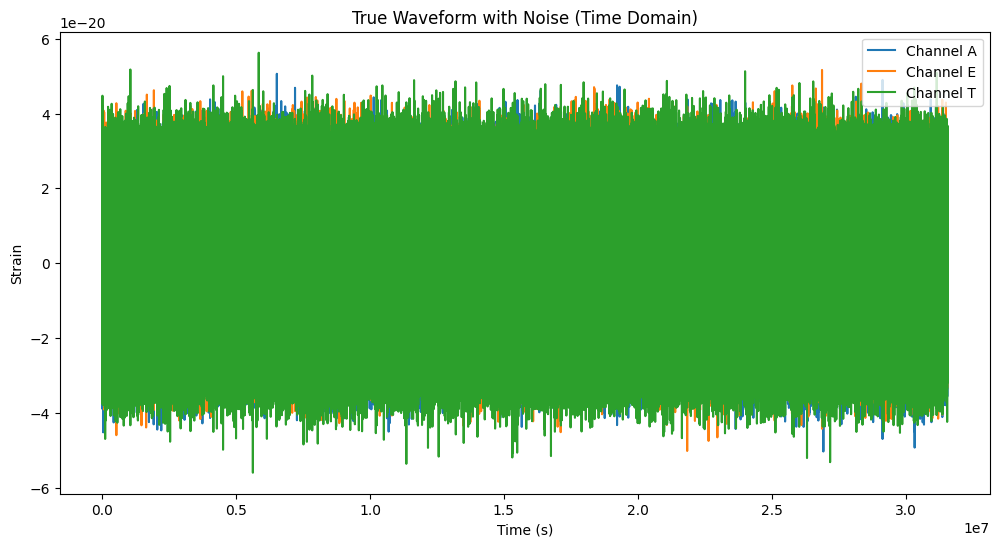

Length of PSD: 3155814


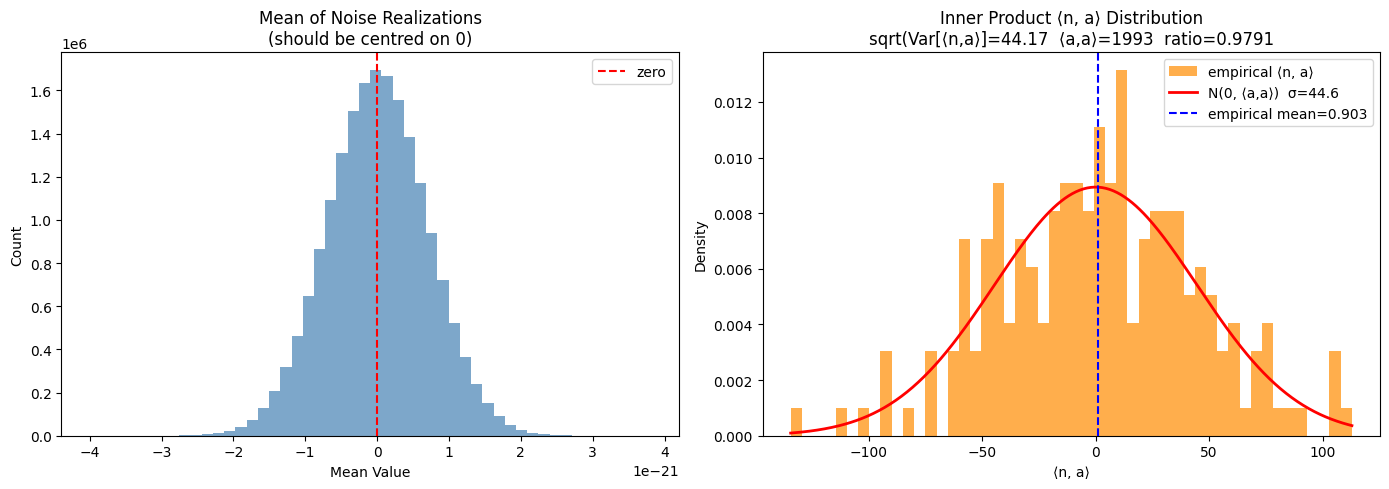

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 6311626  |  PSD bins passed: 3155813
  N (template samples)   : 6311629  →  aligned to 6311626
  Max |mean noise|       : 4.0032e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 9.0326e-01           (expect ≈ 0)
  Var[⟨n, a⟩]           : 1950.89
  ⟨a, a⟩                : 1992.53
  Ratio Var/⟨a,a⟩       : 0.979106          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-8.68921176e-22,  3.54543943e-22,  2.52559991e-22, ...,
         6.30125341e-22, -5.83403466e-22,  7.10403505e-22],
       [-2.08924216e-23,  4.32156119e-24,  1.78857121e-22, ...,
         1.02424805e-21,  2.71873085e-23,  2.46304456e-22],
       [ 5.81954774e-22, -8.54387829e-23,  7.93659288e-23, ...,
         1.00137071e-21, -1.06712954e-21, -1.78807266e-22]],
      shape=(3, 6311626)), 'inner_products': array([ 1.88766651e+01, -4.71163287e+01,  5.15812769e+01,  3.41924805e+0

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 5,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554c80e6120>,
 'PSD_funcs': array([[6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [6.81763650e-35, 1.70440916e-35, 7.57515208e-36, ...,
         4.26636463e-39, 4.26636171e-39, 4.26635879e-39],
        [2.65994852e-56, 1.06395802e-55, 2.39388950e-55, ...,
         1.65107196e-39, 1.65106498e-39, 1.65105800e-39]],
       shape=(3, 3155814)),
 'waveform_true_fft': array([[-6.25689989e-15+4.0676

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          2.5,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 5  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [3]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="2nd generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 6, Ndelta = 12,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, np.float64(1.0), np.float64(5.0), 0.7773862440642697, 1.0071592783261298, np.float64(1.0), np.float64(1.0471975511965976), 0.911151948599342, np.float64(0.5), 0.5318777296989502, 0.0, True, False, False, False, 0, 0)
SNR:  46.57966670031206
Body is not plunging, Fisher should be stable.
waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, np.float64(1.0), np.float64(5.0), 0.7773862440642697, 1.0071592783261298, np.float64(1.0), np.float64(1.0471975511965976), 0.911151948599342, np.float64(0.5), 0.5318777296989502, 0.0, True, False, False, False, 0, 0)
Waveform Generated. SNR: 46.57966670031206
calculating stable deltas...
Gamma_ii for m1: 2313.685896279611
Gamma_ii for m1: 2313.6862225970954
Gamma_ii

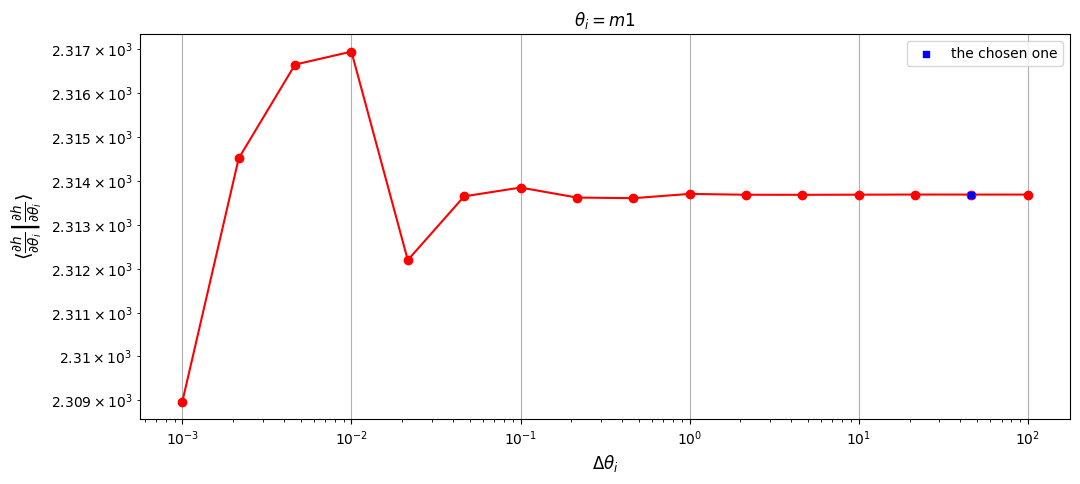

Gamma_ii for m2: 830963339087.6984
Gamma_ii for m2: 830963476470.816
Gamma_ii for m2: 830962418485.767
Gamma_ii for m2: 830965293297.6953
Gamma_ii for m2: 830972020212.9681
Gamma_ii for m2: 830937168599.3607
Gamma_ii for m2: 831024403322.3367
Gamma_ii for m2: 830778136979.0975
Gamma_ii for m2: 830826330133.5386
Gamma_ii for m2: 831236294891.994
Gamma_ii for m2: 830769020425.1117
Gamma_ii for m2: 828087147700.3087
Gamma_ii for m2: 836964865644.6741
Gamma_ii for m2: 835419763074.6234
Gamma_ii for m2: 834834947486.569
Gamma_ii for m2: 818970535774.3624
[np.float64(1.6532991108016074e-07), np.float64(1.2732044500883612e-06), np.float64(3.4596052946278926e-06), np.float64(8.09523679401759e-06), np.float64(4.194253780483576e-05), np.float64(0.00010497251660384233), np.float64(0.0002964285316108792), np.float64(5.800629167986764e-05), np.float64(0.0004931988184042334), np.float64(0.0005624601488428346), np.float64(0.003238635851613977), np.float64(0.010607037772759164), np.float64(0.001849492

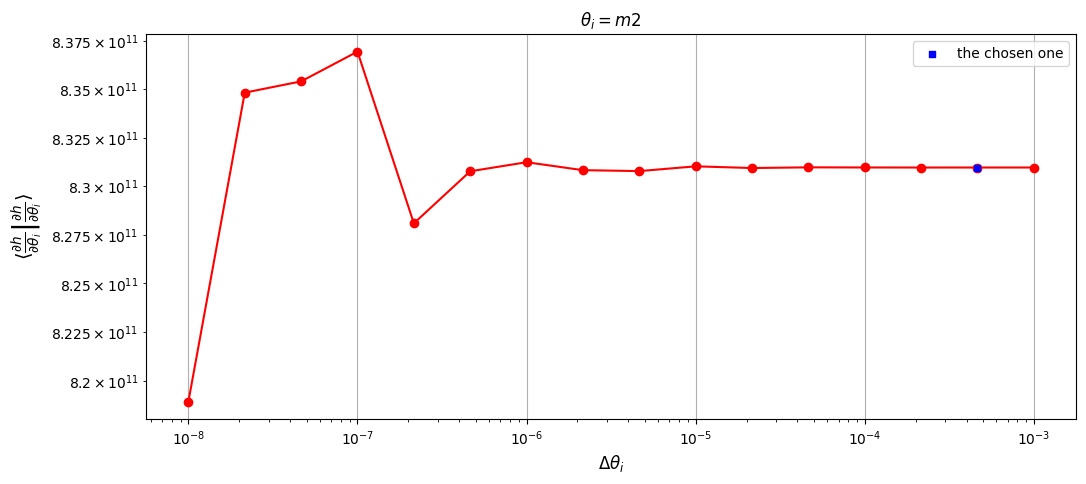

Gamma_ii for a: 52507428881058.336
Gamma_ii for a: 52507389000786.195
Gamma_ii for a: 52507523185780.36
Gamma_ii for a: 52507276135239.84
Gamma_ii for a: 52507020461934.78
Gamma_ii for a: 52506147883605.9
Gamma_ii for a: 52506167967647.266
Gamma_ii for a: 52521347734848.82
Gamma_ii for a: 52503305963873.81
Gamma_ii for a: 52485059145796.81
Gamma_ii for a: 52555221394334.875
Gamma_ii for a: 52403349905148.625
Gamma_ii for a: 52534132426333.6
Gamma_ii for a: 53372149878869.99
Gamma_ii for a: 54177651594551.75
Gamma_ii for a: 57072136223641.05
[np.float64(7.595173345989051e-07), np.float64(2.5555384452108633e-06), np.float64(4.705072490892724e-06), np.float64(4.8693165754444515e-06), np.float64(1.661859351817465e-05), np.float64(3.825082298819195e-07), np.float64(0.0002890209001906981), np.float64(0.0003436311417688992), np.float64(0.00034765737857535154), np.float64(0.0013350195599333076), np.float64(0.00289812558664935), np.float64(0.0024894771293381), np.float64(0.015701399595824814), 

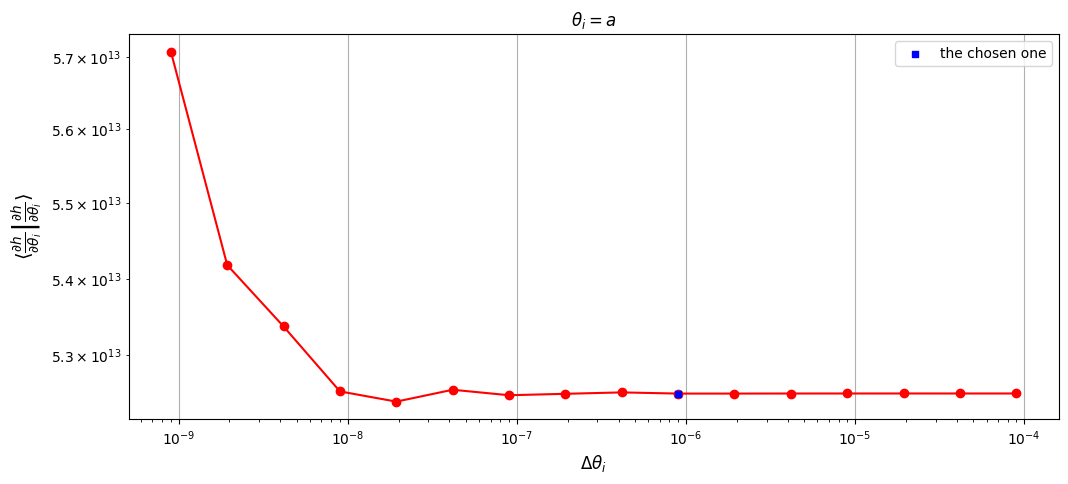

Gamma_ii for p0: 101789965933151.48
Gamma_ii for p0: 101789983893703.89
Gamma_ii for p0: 101789907870179.34
Gamma_ii for p0: 101789884836927.23
Gamma_ii for p0: 101789973373025.19
Gamma_ii for p0: 101789973629134.77
Gamma_ii for p0: 101789928880424.28
Gamma_ii for p0: 101786014925523.7
Gamma_ii for p0: 101784239308921.52
Gamma_ii for p0: 101790421245498.0
Gamma_ii for p0: 101803807192245.9
Gamma_ii for p0: 101815865083188.3
Gamma_ii for p0: 101756451840215.69
Gamma_ii for p0: 101777780026271.2
Gamma_ii for p0: 101648160283965.08
Gamma_ii for p0: 102504024837939.2
[np.float64(1.7644714852303784e-07), np.float64(7.468670140052957e-07), np.float64(2.2628232801594663e-07), np.float64(8.697919354853419e-07), np.float64(2.5160589888560025e-09), np.float64(4.3961825080890537e-07), np.float64(3.8452776675085916e-05), np.float64(1.7444907131431154e-05), np.float64(6.073200700854542e-05), np.float64(0.00013148768319271479), np.float64(0.00011842840929101537), np.float64(0.0005838769129440927), n

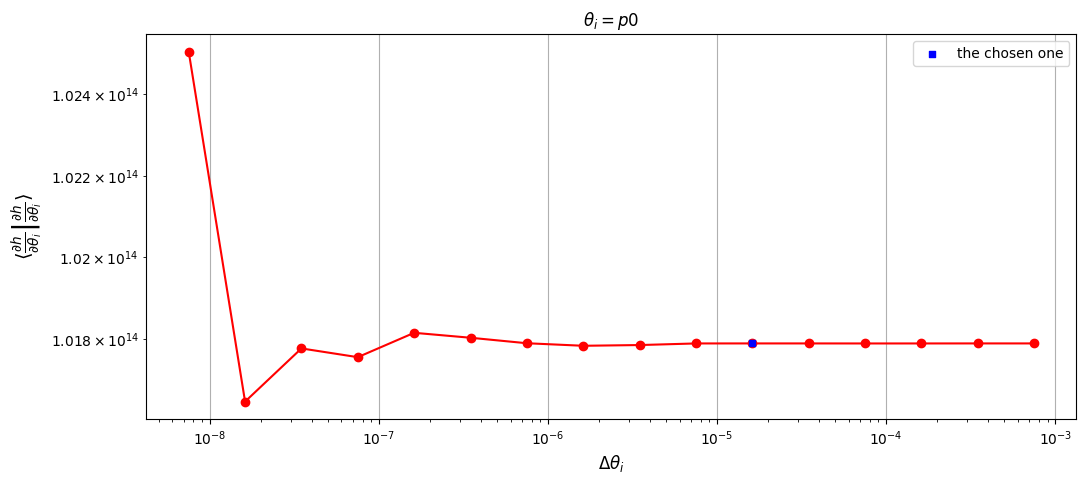

Gamma_ii for e0: 1561687411094557.2
Gamma_ii for e0: 1561685877860955.2
Gamma_ii for e0: 1561686067509351.8
Gamma_ii for e0: 1561694142908071.2
Gamma_ii for e0: 1561682940507522.0
Gamma_ii for e0: 1561684587081363.8
Gamma_ii for e0: 1561661746638771.8
Gamma_ii for e0: 1561781957553553.5
Gamma_ii for e0: 1561722528232480.5
Gamma_ii for e0: 1561068853245507.8
Gamma_ii for e0: 1559996720141412.2
Gamma_ii for e0: 1563364156573485.5
Gamma_ii for e0: 1562012313469474.5
Gamma_ii for e0: 1580494035271434.8
Gamma_ii for e0: 1513181289607983.8
Gamma_ii for e0: 1601821197845044.0
[np.float64(9.817810506809945e-07), np.float64(1.2143823297499218e-07), np.float64(5.170922075985116e-06), np.float64(7.173287393156385e-06), np.float64(1.0543574902197671e-06), np.float64(1.4625729701813095e-05), np.float64(7.697035696971033e-05), np.float64(3.8053700320415215e-05), np.float64(0.0004187355257352939), np.float64(0.0006872662552766855), np.float64(0.002153968042515349), np.float64(0.0008654497101936055), 

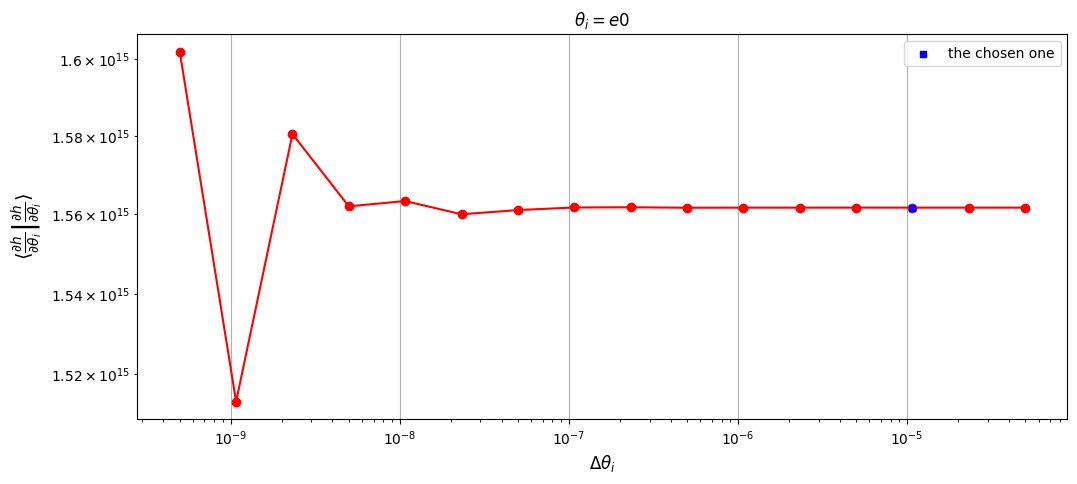

Gamma_ii for qS: 162234.75388752867
Gamma_ii for qS: 179262.82151767003
Gamma_ii for qS: 179328.8691926209
Gamma_ii for qS: 179539.4969913989
Gamma_ii for qS: 179565.75585873105
Gamma_ii for qS: 178431.04218939756
Gamma_ii for qS: 178809.81002509955
Gamma_ii for qS: 184174.87911072848
Gamma_ii for qS: 216157.7787959581
Gamma_ii for qS: 380800.27541634283
Gamma_ii for qS: 265654.65891992295
Gamma_ii for qS: 187200.7112093123
Gamma_ii for qS: 179072.8549999648
Gamma_ii for qS: 179030.7602734408
Gamma_ii for qS: 178706.42934884608
Gamma_ii for qS: 178843.8068121439
[np.float64(0.0949893987274037), np.float64(0.0003683047534300706), np.float64(0.0011731557808032974), np.float64(0.00014623538439488074), np.float64(0.006359396074865922), np.float64(0.00211827212192006), np.float64(0.02913029785350572), np.float64(0.14796090089091746), np.float64(0.4323591847205864), np.float64(0.4334409829835831), np.float64(0.41909000881353453), np.float64(0.045388544284666245), np.float64(0.000235125664772

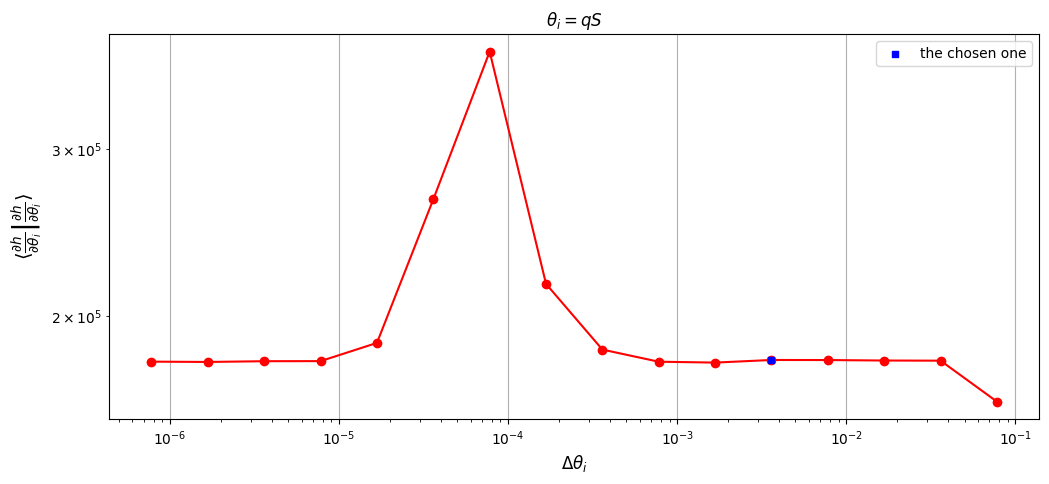

Gamma_ii for phiS: 245333.9473398914
Gamma_ii for phiS: 312506.1306107346
Gamma_ii for phiS: 313377.6777833749
Gamma_ii for phiS: 313298.1909708178
Gamma_ii for phiS: 313369.78547505254
Gamma_ii for phiS: 313573.728603189
Gamma_ii for phiS: 314560.2591394583
Gamma_ii for phiS: 319380.08777797024
Gamma_ii for phiS: 315383.08893333975
Gamma_ii for phiS: 313277.32410928386
Gamma_ii for phiS: 313220.7928441366
Gamma_ii for phiS: 313174.8616543169
Gamma_ii for phiS: 313489.8997856714
Gamma_ii for phiS: 313001.18820294354
Gamma_ii for phiS: 312468.96846252895
Gamma_ii for phiS: 311542.01251696737
[np.float64(0.21494676965078333), np.float64(0.0027811399293181265), np.float64(0.00025370977186554394), np.float64(0.00022846651959823334), np.float64(0.000650383337420883), np.float64(0.0031362211455704943), np.float64(0.015091199554878443), np.float64(0.012673472309973188), np.float64(0.006721727562130592), np.float64(0.0001804837559918763), np.float64(0.0001466630800986948), np.float64(0.0010049

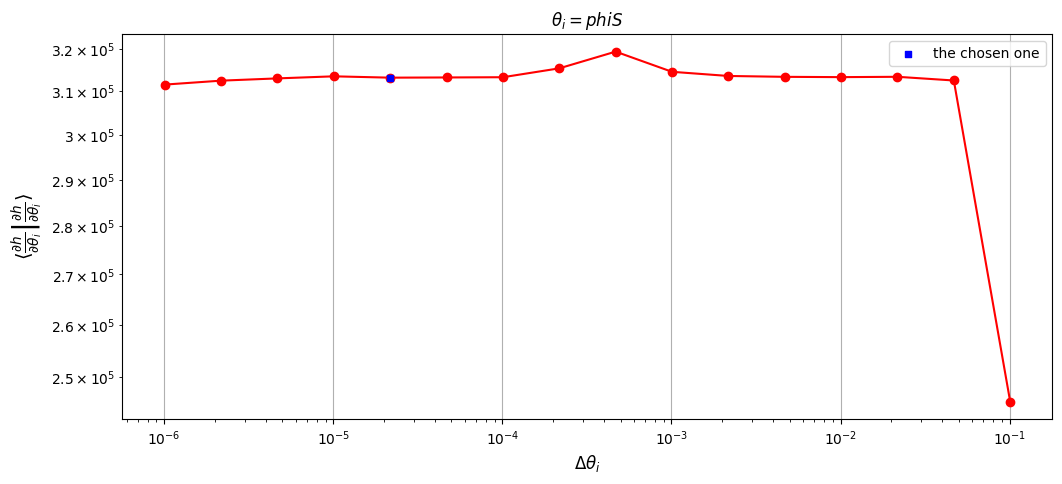

stable deltas: {'m1': 46.42677470051023, 'm2': 0.0004642112820802862, 'a': 9.001561805718662e-07, 'p0': 1.6156058206871525e-05, 'e0': 1.0771620087044526e-05, 'qS': 0.0036083073098528936, 'phiS': 2.169858887613294e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 44.52744483947754 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.0916662216186523 seconds


In [4]:
x_best_fit_1PA = [1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502]

add_kwargs_1PA = {'chi2': 0.0, 'evolve_1PA': True, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': False,
                      'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_1PA['chi2'],add_kwargs_1PA['evolve_1PA'],add_kwargs_1PA['evolve_primary'],
                    add_kwargs_1PA['evolve_2PA'], add_kwargs_1PA['deviation_included'],add_kwargs_1PA['dev_1'],add_kwargs_1PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_1PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_1PA,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 16,return_derivatives = False)




waveform shape: (3, 6311629)
wave ndim: 2


Computing SNR for parameters: (1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, np.float64(1.0), np.float64(5.0), 0.7753479239641903, 1.0071736406662928, np.float64(1.0), np.float64(1.0471975511965976), 0.9247980336593397, np.float64(0.5), 0.527676177865538, 0.0, False, False, False, True, 0, 0)
SNR:  46.562449125871744
Body is not plunging, Fisher should be stable.
waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, np.float64(1.0), np.float64(5.0), 0.7753479239641903, 1.0071736406662928, np.float64(1.0), np.float64(1.0471975511965976), 0.9247980336593397, np.float64(0.5), 0.527676177865538, 0.0, False, False, False, True, 0, 0)
Waveform Generated. SNR: 46.562449125871744
calculating stable deltas...
Gamma_ii for m1: 2312.2225075833853
Gamma_ii for m1: 2312.2225075714446
Gamma_ii for m1: 2312.2225075836586
Gamma_ii 

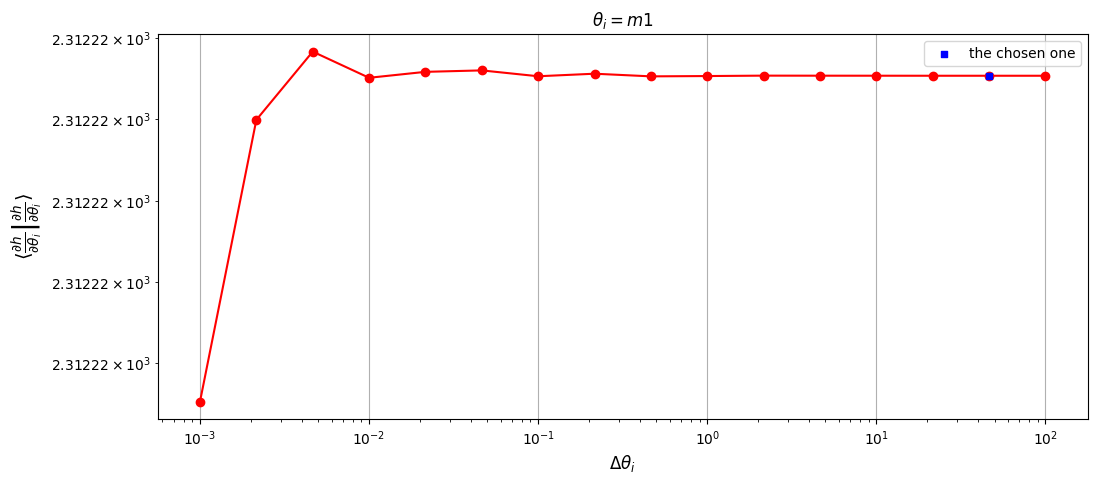

Gamma_ii for m2: 830576942794.5178
Gamma_ii for m2: 830576942782.339
Gamma_ii for m2: 830576942803.1366
Gamma_ii for m2: 830576942774.0157
Gamma_ii for m2: 830576942693.7727
Gamma_ii for m2: 830576942901.0715
Gamma_ii for m2: 830576942463.1772
Gamma_ii for m2: 830576941453.8484
Gamma_ii for m2: 830576943199.5815
Gamma_ii for m2: 830576935490.4288
Gamma_ii for m2: 830576911966.5746
Gamma_ii for m2: 830576969635.4497
Gamma_ii for m2: 830577026729.2876
Gamma_ii for m2: 830576905435.6628
Gamma_ii for m2: 830576743639.3127
Gamma_ii for m2: 830576570710.9246
[np.float64(1.4663100286669148e-11), np.float64(2.5039952772689055e-11), np.float64(3.5060989668356625e-11), np.float64(9.661120826679689e-11), np.float64(2.4958413533722545e-10), np.float64(5.272170038946014e-10), np.float64(1.215214156626041e-09), np.float64(2.1018319477686106e-09), np.float64(9.281684068687667e-09), np.float64(2.832230695210266e-08), np.float64(6.943230697497172e-08), np.float64(6.873996758067541e-08), np.float64(1.46

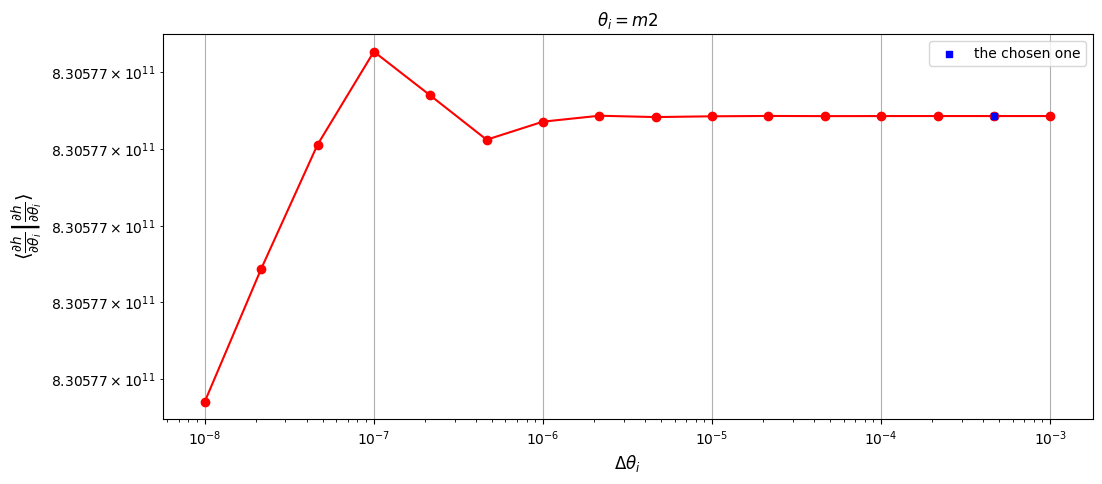

Gamma_ii for a: 52503168845340.73
Gamma_ii for a: 52503192962987.8
Gamma_ii for a: 52502966556755.79
Gamma_ii for a: 52503404275025.414
Gamma_ii for a: 52501836573496.27
Gamma_ii for a: 52503185804069.5
Gamma_ii for a: 52504785865481.84
Gamma_ii for a: 52506713678011.016
Gamma_ii for a: 52515582234666.7
Gamma_ii for a: 52473761965483.6
Gamma_ii for a: 52546409962668.88
Gamma_ii for a: 52875010266675.19
Gamma_ii for a: 52780250514222.85
Gamma_ii for a: 51555186915733.32
Gamma_ii for a: 51901949143503.2
Gamma_ii for a: 49406097827630.35
[np.float64(4.5935581646080596e-07), np.float64(4.312255989631881e-06), np.float64(8.336950254351637e-06), np.float64(2.9859936936606607e-05), np.float64(2.5698070556358204e-05), np.float64(3.0474582192243094e-05), np.float64(3.671554348257016e-05), np.float64(0.00016887476589440094), np.float64(0.0007969748616577227), np.float64(0.0013825492024458637), np.float64(0.006214661753236711), np.float64(0.0017953638250883396), np.float64(0.02376217936115509), n

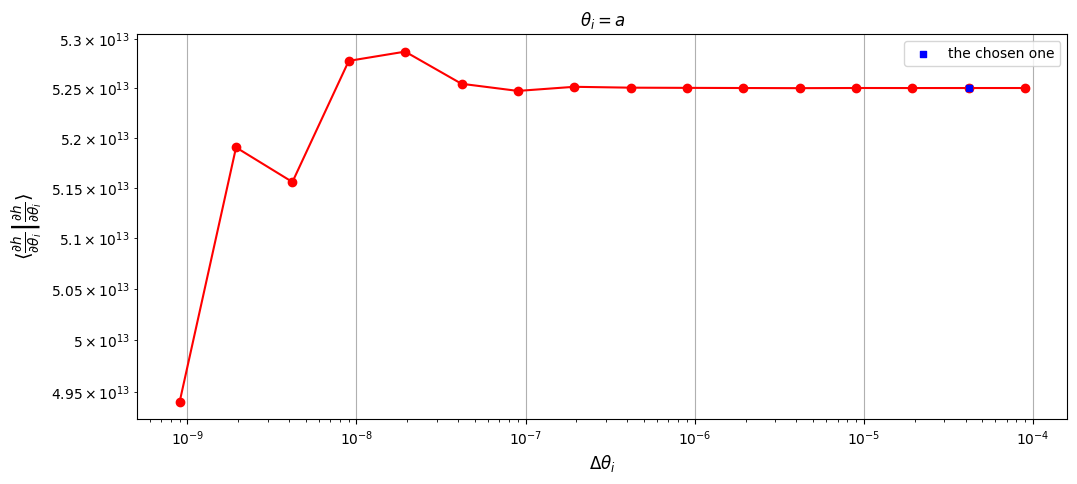

Gamma_ii for p0: 101768520307246.53
Gamma_ii for p0: 101768499176839.14
Gamma_ii for p0: 101768530423526.89
Gamma_ii for p0: 101768442412426.0
Gamma_ii for p0: 101768431434358.27
Gamma_ii for p0: 101768372649506.61
Gamma_ii for p0: 101769140775720.97
Gamma_ii for p0: 101769584851901.56
Gamma_ii for p0: 101771394476041.44
Gamma_ii for p0: 101769637316635.11
Gamma_ii for p0: 101776210703035.36
Gamma_ii for p0: 101784182434889.05
Gamma_ii for p0: 101848474526544.97
Gamma_ii for p0: 101572600139373.94
Gamma_ii for p0: 101548532677840.28
Gamma_ii for p0: 101468716911840.58
[np.float64(2.0763210189341122e-07), np.float64(3.070368376153379e-07), np.float64(8.648172144951566e-07), np.float64(1.078730170018978e-07), np.float64(5.776337984562928e-07), np.float64(7.547732136720826e-06), np.float64(4.3635451715754194e-06), np.float64(1.778126505185122e-05), np.float64(1.7266047641116065e-05), np.float64(6.458666868066013e-05), np.float64(7.831994778547233e-05), np.float64(0.0006312523771690395), n

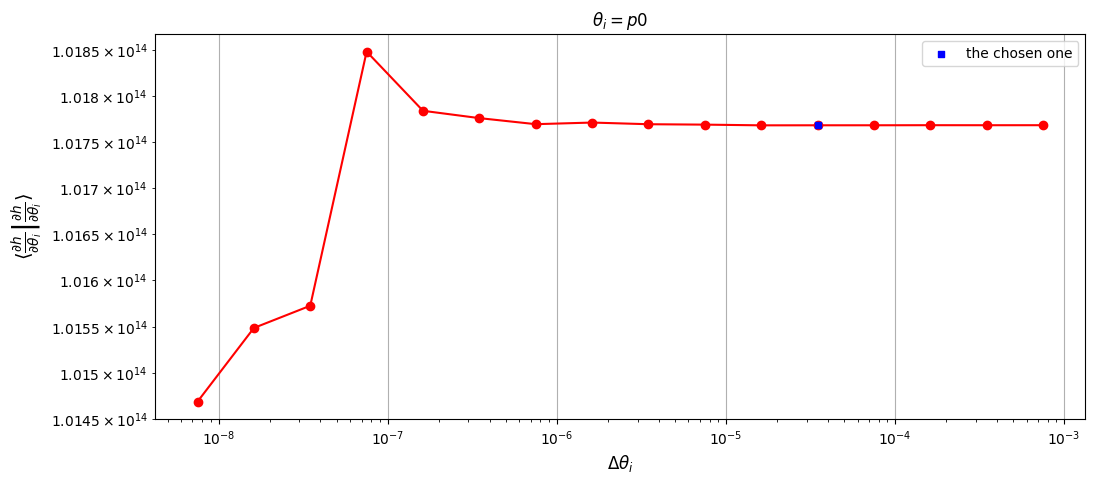

Gamma_ii for e0: 1560699585814470.2
Gamma_ii for e0: 1560701181175795.5
Gamma_ii for e0: 1560698150280497.2
Gamma_ii for e0: 1560699170783747.0
Gamma_ii for e0: 1560709267163519.0
Gamma_ii for e0: 1560689333901704.8
Gamma_ii for e0: 1560680241950864.0
Gamma_ii for e0: 1560714113942483.8
Gamma_ii for e0: 1560665136069853.2
Gamma_ii for e0: 1561272404993932.8
Gamma_ii for e0: 1560393629061746.8
Gamma_ii for e0: 1560989863088976.0
Gamma_ii for e0: 1564184045054053.0
Gamma_ii for e0: 1555758256627202.5
Gamma_ii for e0: 1559452575270724.0
Gamma_ii for e0: 1558576619436246.0
[np.float64(1.02220805910334e-06), np.float64(1.9420124882606356e-06), np.float64(6.538756916475626e-07), np.float64(6.469097085807321e-06), np.float64(1.277208819286096e-05), np.float64(5.825633333696198e-06), np.float64(2.1702880314311213e-05), np.float64(3.138269158356326e-05), np.float64(0.00038895770023031947), np.float64(0.0005631758011690945), np.float64(0.0003819589360108899), np.float64(0.0020420755314420943), n

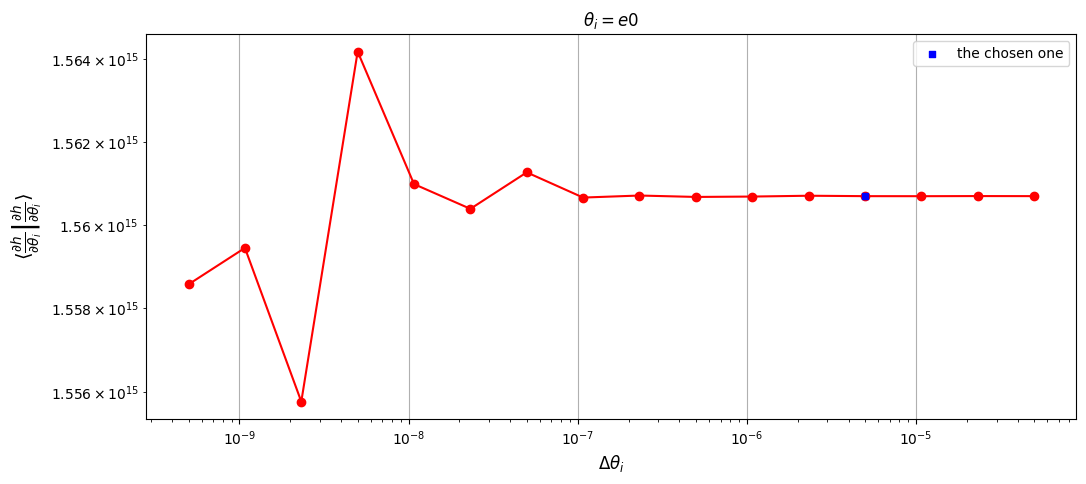

Gamma_ii for qS: 163087.8964408139
Gamma_ii for qS: 180392.4656498422
Gamma_ii for qS: 180413.90749995157
Gamma_ii for qS: 180687.9694708449
Gamma_ii for qS: 180233.14954944627
Gamma_ii for qS: 179662.5425759354
Gamma_ii for qS: 179966.88632272012
Gamma_ii for qS: 182555.2329521544
Gamma_ii for qS: 179778.20904775203
Gamma_ii for qS: 180391.43801372199
Gamma_ii for qS: 180005.53163039617
Gamma_ii for qS: 181354.37646926512
Gamma_ii for qS: 179520.61826445576
Gamma_ii for qS: 179807.31619827996
Gamma_ii for qS: 180584.35804094753
Gamma_ii for qS: 180466.17376277357
[np.float64(0.09592733901990122), np.float64(0.00011884809994141299), np.float64(0.001516769332767029), np.float64(0.00252350870267539), np.float64(0.0031759929773325208), np.float64(0.001691109698030615), np.float64(0.014178430207545138), np.float64(0.015446943871071378), np.float64(0.003399434988279837), np.float64(0.0021438584682952396), np.float64(0.007437619456057282), np.float64(0.010214749829504327), np.float64(0.00159

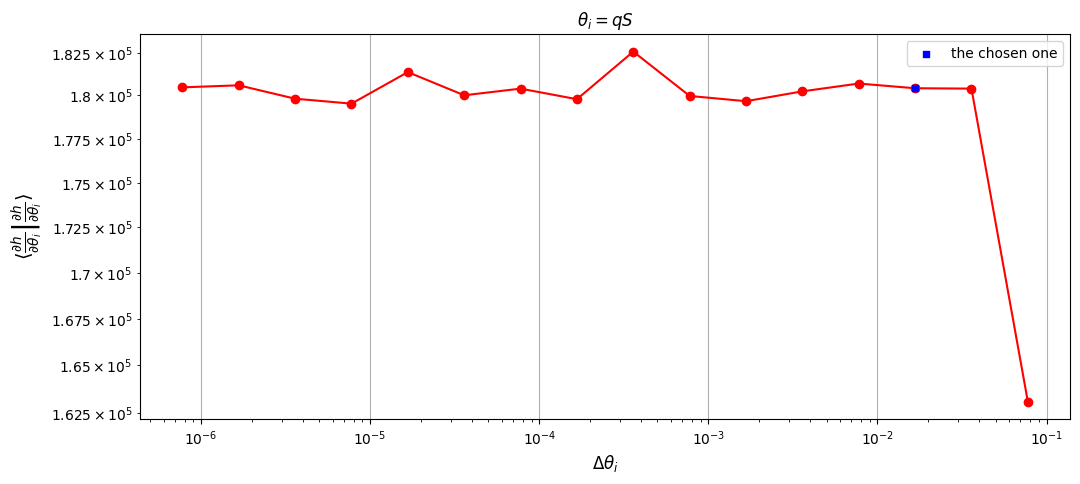

Gamma_ii for phiS: 243943.7947943716
Gamma_ii for phiS: 309185.6513496182
Gamma_ii for phiS: 310000.94248115027
Gamma_ii for phiS: 309939.268634127
Gamma_ii for phiS: 309994.547441564
Gamma_ii for phiS: 309912.16596403025
Gamma_ii for phiS: 309895.5712859179
Gamma_ii for phiS: 309919.73955970677
Gamma_ii for phiS: 310001.77936332725
Gamma_ii for phiS: 309983.74302271666
Gamma_ii for phiS: 310279.30902943824
Gamma_ii for phiS: 309024.52078643086
Gamma_ii for phiS: 312021.3063115227
Gamma_ii for phiS: 307648.1180728781
Gamma_ii for phiS: 308127.808958216
Gamma_ii for phiS: 309985.4053630256
[np.float64(0.21101191556096177), np.float64(0.0026299633962616957), np.float64(0.00019898687667126554), np.float64(0.00017832187015292446), np.float64(0.0002658220185627846), np.float64(5.35492586857694e-05), np.float64(7.798236350873274e-05), np.float64(0.00026464300878845614), np.float64(5.818479522414202e-05), np.float64(0.0009525804593484421), np.float64(0.004060481154744914), np.float64(0.009604

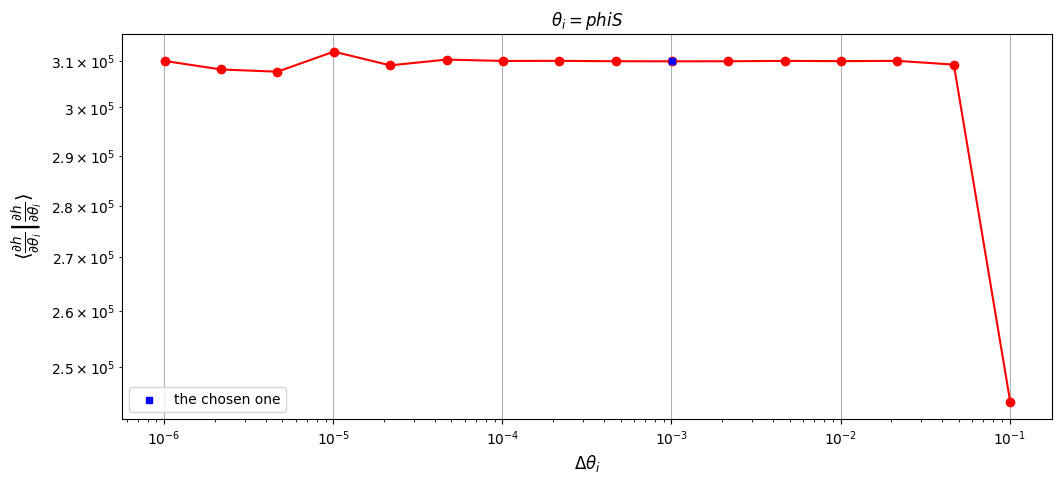

stable deltas: {'m1': 46.43360547208824, 'm2': 0.00046425954528819585, 'a': 4.178598195434128e-05, 'p0': 3.480453480925228e-05, 'e0': 4.9994934399028556e-06, 'qS': 0.016704364642326556, 'phiS': 0.0010071736406662922, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 43.5760383605957 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.014803886413574 seconds


In [5]:
x_best_fit_0PA = [1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, 0.7753479239641903, 1.0071736406662928, 0.9247980336593397, 0.527676177865538]

add_kwargs_0PA = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': 0, 'dev_2': 0}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA['chi2'],add_kwargs_0PA['evolve_1PA'],add_kwargs_0PA['evolve_primary'],
                    add_kwargs_0PA['evolve_2PA'], add_kwargs_0PA['deviation_included'],add_kwargs_0PA['dev_1'],add_kwargs_0PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 16,return_derivatives = False)


In [6]:
np.save("emri_results_corrected/Fisher_1PA.npy", Fisher_1PA)
np.save("emri_results_corrected/Fisher_0PA.npy", Fisher_0PA)

waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1002038.3206946955, 10.025942269951084, 0.9011207263816821, 7.492941363053822, 0.499560753899444, np.float64(1.0), np.float64(5.0), 0.8016696937534229, 1.00378495940247, np.float64(1.0), np.float64(1.0471975511965976), 0.9154248514732031, np.float64(0.5), 0.4958258737144708, 0.0, False, False, False, True, -92.01945190544691, -0.00016624654748756643)
SNR:  46.89525888788297
Body is not plunging, Fisher should be stable.
waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1002038.3206946955, 10.025942269951084, 0.9011207263816821, 7.492941363053822, 0.499560753899444, np.float64(1.0), np.float64(5.0), 0.8016696937534229, 1.00378495940247, np.float64(1.0), np.float64(1.0471975511965976), 0.9154248514732031, np.float64(0.5), 0.4958258737144708, 0.0, False, False, False, True, -92.01945190544691, -0.00016624654748756643)
Waveform Generated. SNR: 46.89525888788297
calculating stable deltas...
Gamma

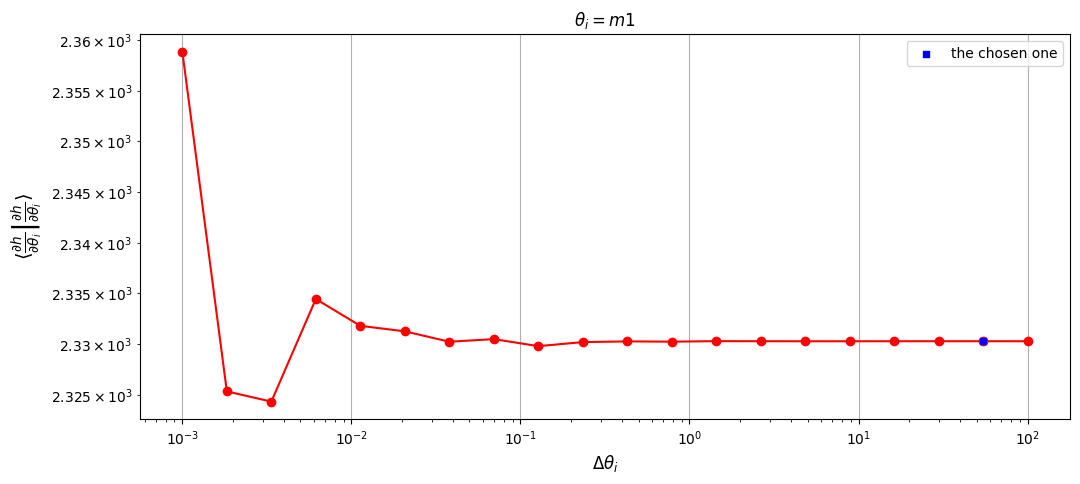

Gamma_ii for m2: 836987796397.5486
Gamma_ii for m2: 836987659049.379
Gamma_ii for m2: 836988877306.458
Gamma_ii for m2: 836985460565.5298
Gamma_ii for m2: 836984536967.6129
Gamma_ii for m2: 836989853841.0137
Gamma_ii for m2: 836966866432.4097
Gamma_ii for m2: 836994917511.2819
Gamma_ii for m2: 836893323680.1198
Gamma_ii for m2: 837045273500.8467
Gamma_ii for m2: 836807610747.9633
Gamma_ii for m2: 836162765183.1613
Gamma_ii for m2: 837454228328.8304
Gamma_ii for m2: 836874625988.5999
Gamma_ii for m2: 838574106947.8622
Gamma_ii for m2: 839610592772.2979
Gamma_ii for m2: 845135295195.0083
Gamma_ii for m2: 826482638928.083
Gamma_ii for m2: 827930401784.3118
Gamma_ii for m2: 891285664023.1343
[np.float64(1.640982015334124e-07), np.float64(1.4555236180676692e-06), np.float64(4.08219866318114e-06), np.float64(1.1034826523991754e-06), np.float64(6.352374973671756e-06), np.float64(2.746513574902703e-05), np.float64(3.351403728423988e-05), np.float64(0.00012139400361728888), np.float64(0.0001815

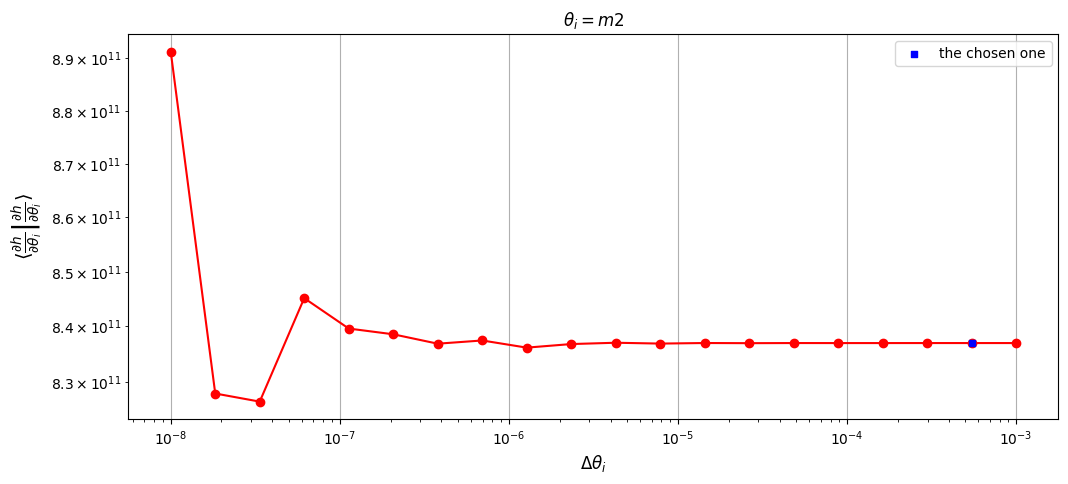

Gamma_ii for a: 52958713780939.39
Gamma_ii for a: 52958755054997.125
Gamma_ii for a: 52958863602155.945
Gamma_ii for a: 52958611400289.34
Gamma_ii for a: 52958808444128.96
Gamma_ii for a: 52960131697272.74
Gamma_ii for a: 52959794027776.84
Gamma_ii for a: 52958571810459.86
Gamma_ii for a: 52955866219752.43
Gamma_ii for a: 52967556207411.89
Gamma_ii for a: 52934577390158.445
Gamma_ii for a: 52909796773743.25
Gamma_ii for a: 52915029305446.984
Gamma_ii for a: 52991924129856.02
Gamma_ii for a: 52980405675156.64
Gamma_ii for a: 52874034955199.28
Gamma_ii for a: 52151389905919.945
Gamma_ii for a: 51821763652096.01
Gamma_ii for a: 54468484531655.266
Gamma_ii for a: 50847880522098.96
[np.float64(7.793623111327355e-07), np.float64(2.0496504539023673e-06), np.float64(4.762244702665761e-06), np.float64(3.7207000196212283e-06), np.float64(2.4985835596957037e-05), np.float64(6.3759593876315585e-06), np.float64(2.307874391625823e-05), np.float64(5.109142575823843e-05), np.float64(0.0002207009062997

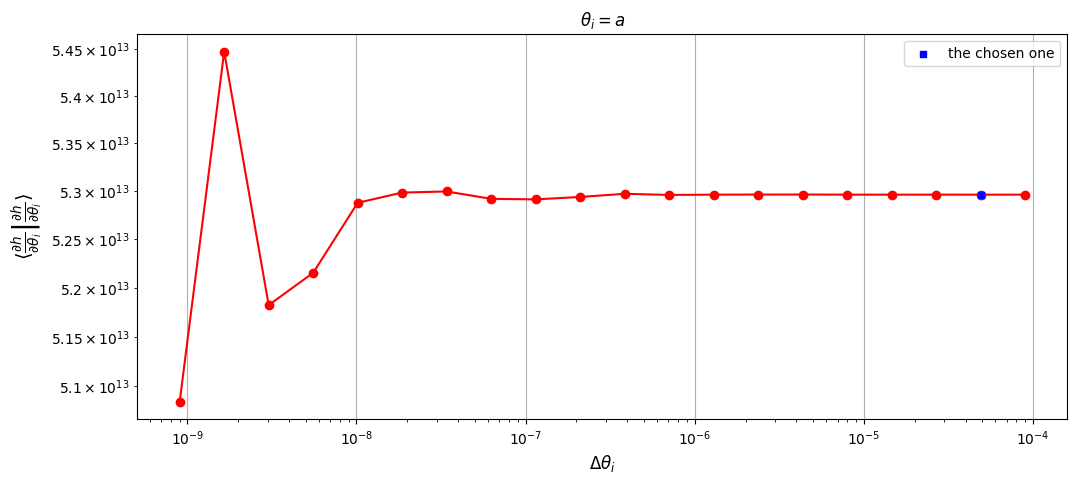

Gamma_ii for p0: 102994728789714.33
Gamma_ii for p0: 102994760050040.1
Gamma_ii for p0: 102994767858986.2
Gamma_ii for p0: 102994799747092.9
Gamma_ii for p0: 102994765504655.19
Gamma_ii for p0: 102994647601210.7
Gamma_ii for p0: 102994661569367.2
Gamma_ii for p0: 102994623196548.69
Gamma_ii for p0: 102994125235871.67
Gamma_ii for p0: 102994431382429.12
Gamma_ii for p0: 102989452888539.34
Gamma_ii for p0: 102999214068419.36
Gamma_ii for p0: 103002164803107.64
Gamma_ii for p0: 102983741905854.33
Gamma_ii for p0: 103027026619325.75
Gamma_ii for p0: 103014914836952.58
Gamma_ii for p0: 103026761482030.69
Gamma_ii for p0: 102942097068728.44
Gamma_ii for p0: 103153145768790.44
Gamma_ii for p0: 103244682364179.62
[np.float64(3.0351374915031737e-07), np.float64(7.581886217818856e-08), np.float64(3.0960890046320093e-07), np.float64(3.324677477633783e-07), np.float64(1.1447531229087777e-06), np.float64(1.3562019901965895e-07), np.float64(3.725710850205903e-07), np.float64(4.834845442642694e-06), 

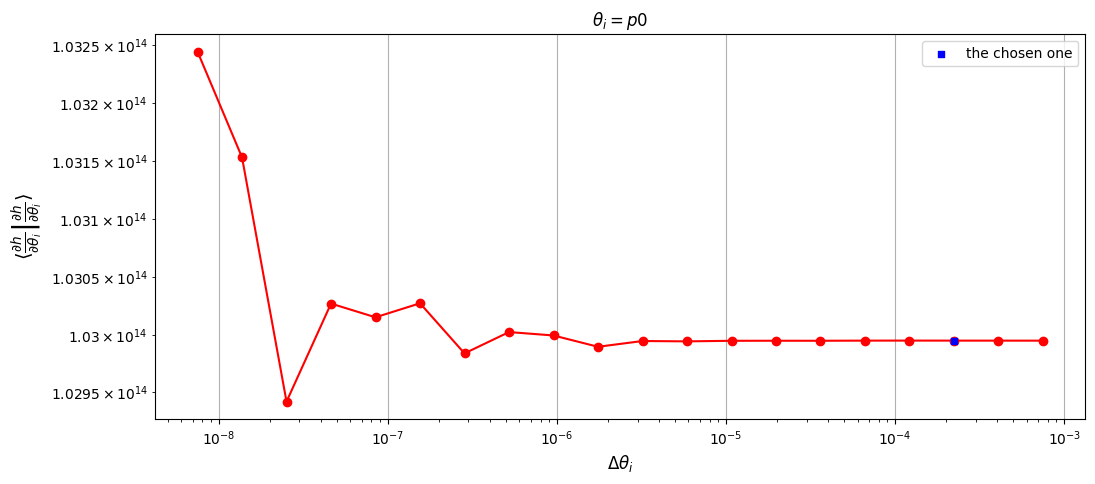

Gamma_ii for e0: 1570208723283844.0
Gamma_ii for e0: 1570210355198255.2
Gamma_ii for e0: 1570208521520047.0
Gamma_ii for e0: 1570207302764290.2
Gamma_ii for e0: 1570211667787397.2
Gamma_ii for e0: 1570207879566236.0
Gamma_ii for e0: 1570219424279599.5
Gamma_ii for e0: 1570197873550625.0
Gamma_ii for e0: 1570207409999431.8
Gamma_ii for e0: 1570121299180018.8
Gamma_ii for e0: 1570363238112696.5
Gamma_ii for e0: 1570407455167672.0
Gamma_ii for e0: 1569353829729867.5
Gamma_ii for e0: 1569083156922004.5
Gamma_ii for e0: 1570003012410588.2
Gamma_ii for e0: 1572003072102070.5
Gamma_ii for e0: 1573747963235984.5
Gamma_ii for e0: 1572678677233765.2
Gamma_ii for e0: 1559329970659278.2
Gamma_ii for e0: 1557938446228791.2
[np.float64(1.0392966813952479e-06), np.float64(1.1677928014776661e-06), np.float64(7.761750659320122e-07), np.float64(2.7798947088138777e-06), np.float64(2.412560279786955e-06), np.float64(7.352293052161545e-06), np.float64(1.3724849165518361e-05), np.float64(6.073368872175588e-

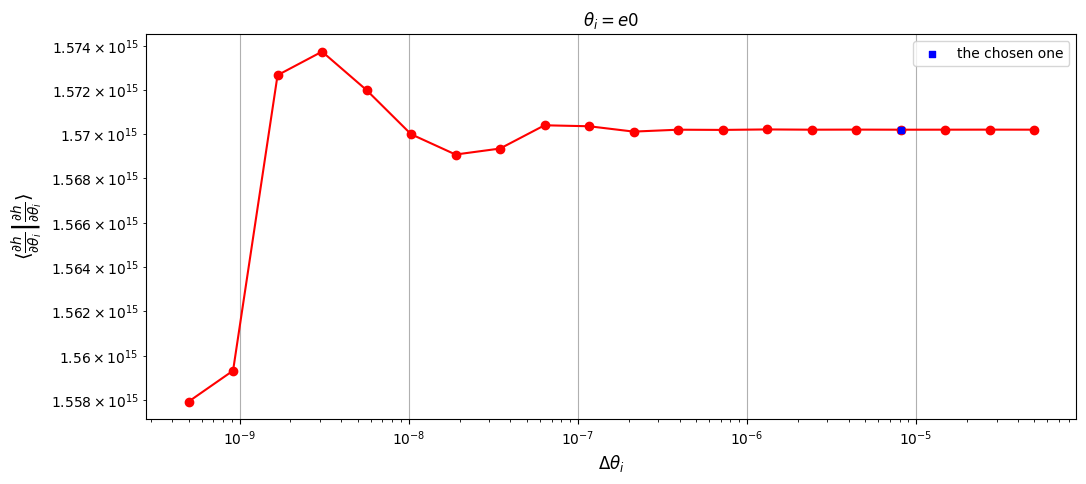

Gamma_ii for qS: 174480.78950486673
Gamma_ii for qS: 163288.16422296624
Gamma_ii for qS: 163238.64830448676
Gamma_ii for qS: 162860.14088967413
Gamma_ii for qS: 163122.45926053118
Gamma_ii for qS: 162967.29981877154
Gamma_ii for qS: 163094.3940290125
Gamma_ii for qS: 163050.7969065288
Gamma_ii for qS: 163041.3130270735
Gamma_ii for qS: 163047.22966866035
Gamma_ii for qS: 163046.74537374973
Gamma_ii for qS: 162989.5719481321
Gamma_ii for qS: 163131.07055942528
Gamma_ii for qS: 163309.8280798041
Gamma_ii for qS: 162543.2494616313
Gamma_ii for qS: 164981.16516951134
Gamma_ii for qS: 166952.41302794978
Gamma_ii for qS: 166001.40794781502
Gamma_ii for qS: 167542.36230286874
Gamma_ii for qS: 168242.8273088871
[np.float64(0.06854523311694052), np.float64(0.0003033345288862862), np.float64(0.0023241255518073067), np.float64(0.001608107013872818), np.float64(0.000952089418749534), np.float64(0.0007792678037624783), np.float64(0.00026738368233002153), np.float64(5.816856647678679e-05), np.float6

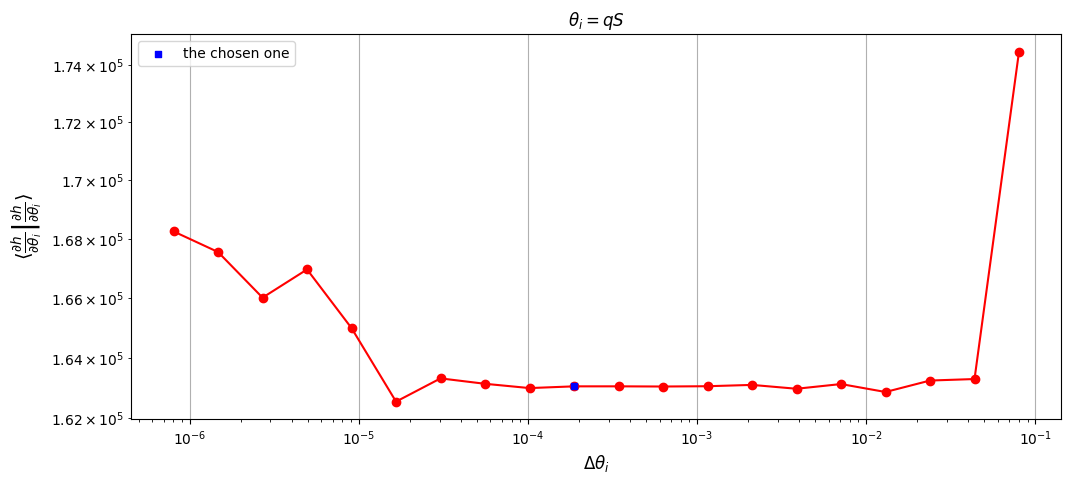

Gamma_ii for phiS: 263124.09901543014
Gamma_ii for phiS: 356095.19311562245
Gamma_ii for phiS: 360657.64203441894
Gamma_ii for phiS: 360689.001323828
Gamma_ii for phiS: 360684.5991337334
Gamma_ii for phiS: 360687.15686477814
Gamma_ii for phiS: 360677.4470991834
Gamma_ii for phiS: 360696.2846369282
Gamma_ii for phiS: 360679.84614325344
Gamma_ii for phiS: 360680.63828093844
Gamma_ii for phiS: 360695.29168112675
Gamma_ii for phiS: 360431.7112056739
Gamma_ii for phiS: 361072.8353547312
Gamma_ii for phiS: 361340.057515957
Gamma_ii for phiS: 362158.739921031
Gamma_ii for phiS: 358736.6045816242
Gamma_ii for phiS: 363921.0171921622
Gamma_ii for phiS: 372950.6617317233
Gamma_ii for phiS: 367042.5929298508
Gamma_ii for phiS: 372918.30225691583
[np.float64(0.2610849455359119), np.float64(0.012650359751315298), np.float64(8.694273818711313e-05), np.float64(1.2205095823757767e-05), np.float64(7.091272855247353e-06), np.float64(2.6920911392814506e-05), np.float64(5.2225483175527036e-05), np.float64

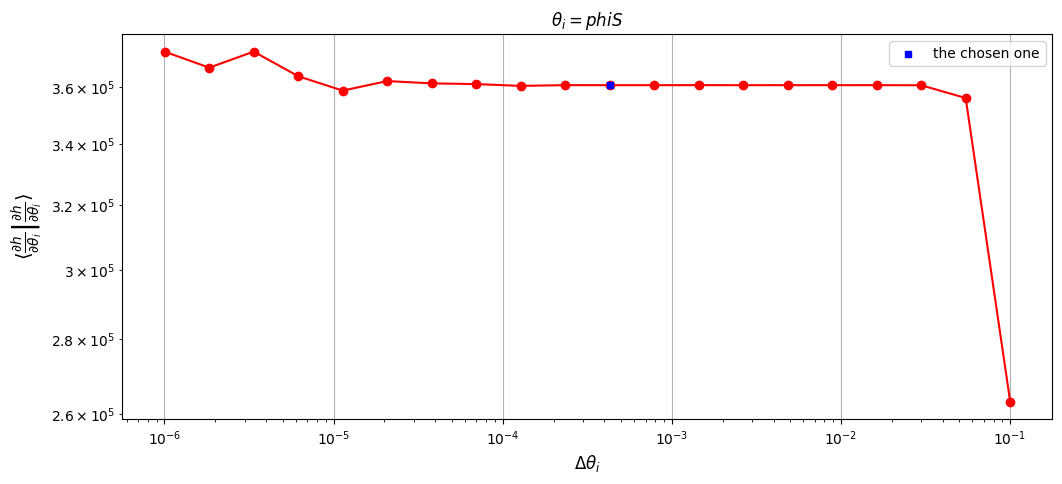

Gamma_ii for dev_1: 4745.9399202368495
Gamma_ii for dev_1: 4745.947604896566
Gamma_ii for dev_1: 4745.930148132801
Gamma_ii for dev_1: 4745.901917366931
Gamma_ii for dev_1: 4745.940675729827
Gamma_ii for dev_1: 4746.025840223453
Gamma_ii for dev_1: 4745.925088210342
Gamma_ii for dev_1: 4745.364241869535
Gamma_ii for dev_1: 4746.254922441657
Gamma_ii for dev_1: 4745.875046385235
Gamma_ii for dev_1: 4746.496910939506
Gamma_ii for dev_1: 4748.2657947492835
Gamma_ii for dev_1: 4737.381283341082
Gamma_ii for dev_1: 4741.274679053884
Gamma_ii for dev_1: 4751.955990289494
Gamma_ii for dev_1: 4759.077690906022
Gamma_ii for dev_1: 4761.945023949876
Gamma_ii for dev_1: 4619.713040279513
Gamma_ii for dev_1: 5094.831824573767
Gamma_ii for dev_1: 5119.530537970868
[np.float64(1.6192044995943918e-06), np.float64(3.6782597341656697e-06), np.float64(5.948451181979693e-06), np.float64(8.166634508003094e-06), np.float64(1.79443805182691e-05), np.float64(2.122916212077069e-05), np.float64(0.0001181882595

/home/svu/e1583490/packages_to_install/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


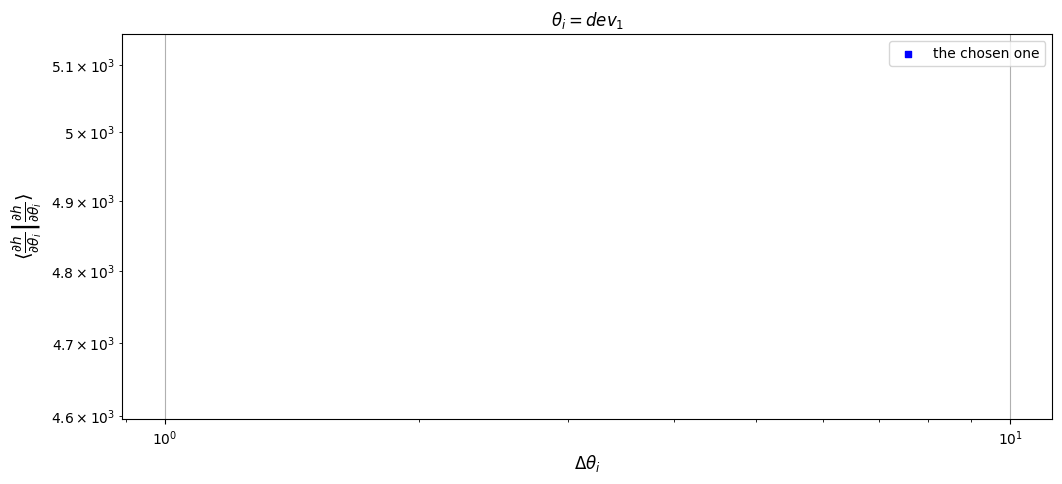

Gamma_ii for dev_2: 448.3278762558083
Gamma_ii for dev_2: 3240.7679389331215
Gamma_ii for dev_2: 9809.027441095408
Gamma_ii for dev_2: 5016.171939735693
Gamma_ii for dev_2: 8228.177867226983
Gamma_ii for dev_2: 15699.919151481663
Gamma_ii for dev_2: 492203.50017079076
Gamma_ii for dev_2: 777475.9622022605
Gamma_ii for dev_2: 197083.59320088587
Gamma_ii for dev_2: 14578503.191005299
Gamma_ii for dev_2: 30657754.18857431
Gamma_ii for dev_2: 58074898.52144299
Gamma_ii for dev_2: 710567688.0338789
Gamma_ii for dev_2: 309574548.8713823
Gamma_ii for dev_2: 8871922945.514164
Gamma_ii for dev_2: 45970734814.26459
Gamma_ii for dev_2: 184462642917.67834
Gamma_ii for dev_2: 137403865124.95065
Gamma_ii for dev_2: 157130192737.48526
Gamma_ii for dev_2: 941327979964.5469
[np.float64(0.8616599877856727), np.float64(0.669613735062483), np.float64(0.9554807049959806), np.float64(0.39036661327956723), np.float64(0.4759095389067365), np.float64(0.9681027884888387), np.float64(0.3669212630361118), np.floa

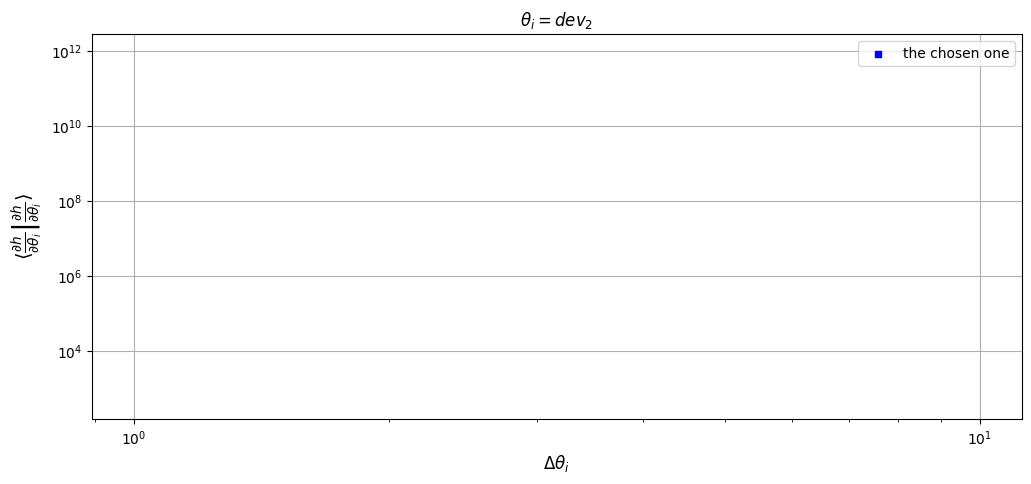

stable deltas: {'m1': 54.66715032912847, 'm2': 0.00054697478324242, 'a': 4.916149532050686e-05, 'p0': 0.00022301626827984174, 'e0': 8.111751319934983e-06, 'qS': 0.00018724771148187754, 'phiS': 0.00042975370680370286, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': -5.020208415813437, 'dev_2': -3.0472671478719826e-10}
Time taken to compute stable deltas is 63.52972078323364 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.5817034244537354 seconds


In [7]:
x_best_fit_0PA_dev =[1002038.3206946955, 10.025942269951084, 0.9011207263816821, 7.492941363053822, 0.499560753899444, 0.8016696937534229, 1.00378495940247, 0.9154248514732031, 0.4958258737144708, -92.01945190544691, -0.00016624654748756643]
add_kwargs_0PA_dev = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': x_best_fit_0PA_dev[9], 'dev_2': x_best_fit_0PA_dev[10]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA_dev  = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)



waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000390.0111866979, 10.002306562504852, 0.9002559335743208, 7.49838263639546, 0.49994741610777566, np.float64(1.0), np.float64(5.0), 0.7756752445526642, 1.0079314684455698, np.float64(1.0), np.float64(1.0471975511965976), 0.9262021678310152, np.float64(0.5), 0.5305190074473904, 0.0, False, False, False, True, -0.6581992660737483, -0.00012710912431291273)
SNR:  46.57110428309638
Body is not plunging, Fisher should be stable.
waveform shape: (3, 6311629)
wave ndim: 2
Computing SNR for parameters: (1000390.0111866979, 10.002306562504852, 0.9002559335743208, 7.49838263639546, 0.49994741610777566, np.float64(1.0), np.float64(5.0), 0.7756752445526642, 1.0079314684455698, np.float64(1.0), np.float64(1.0471975511965976), 0.9262021678310152, np.float64(0.5), 0.5305190074473904, 0.0, False, False, False, True, -0.6581992660737483, -0.00012710912431291273)
Waveform Generated. SNR: 46.57110428309638
calculating stable deltas.

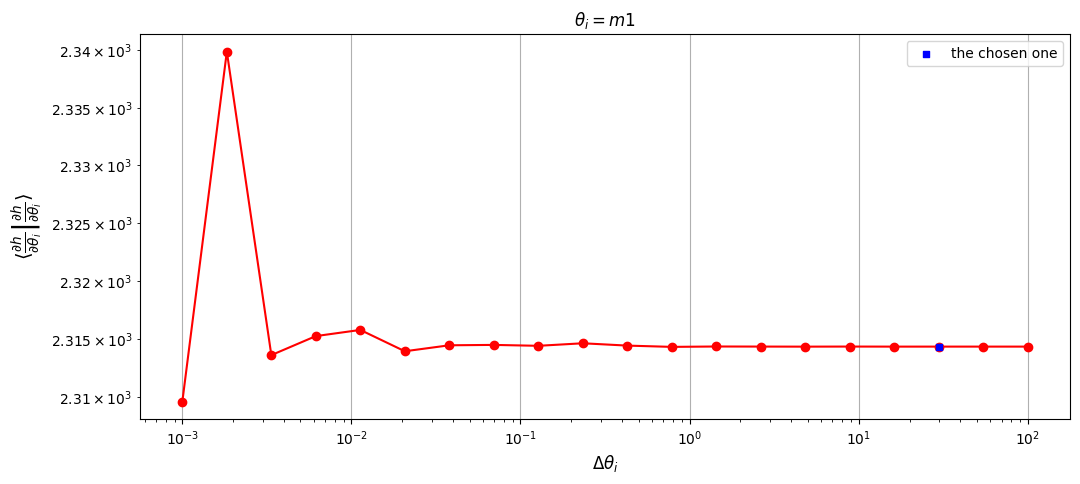

Gamma_ii for m2: 831604881930.7374
Gamma_ii for m2: 831603867845.6262
Gamma_ii for m2: 831603583650.3274
Gamma_ii for m2: 831603311543.265
Gamma_ii for m2: 831602417699.1859
Gamma_ii for m2: 831601977735.1965
Gamma_ii for m2: 831609750122.4718
Gamma_ii for m2: 831625890161.885
Gamma_ii for m2: 831536135224.9266
Gamma_ii for m2: 831766885528.3553
Gamma_ii for m2: 832157166976.3147
Gamma_ii for m2: 831759191816.7332
Gamma_ii for m2: 831891862022.4965
Gamma_ii for m2: 831880366018.0051
Gamma_ii for m2: 830864078700.5905
Gamma_ii for m2: 834072306289.6946
Gamma_ii for m2: 833432006820.6466
Gamma_ii for m2: 829769838419.0875
Gamma_ii for m2: 882091105179.3866
Gamma_ii for m2: 823656554162.7036
[np.float64(1.2194328939729068e-06), np.float64(3.4174371589483606e-07), np.float64(3.2720776673310905e-07), np.float64(1.0748454550848734e-06), np.float64(5.290559680703148e-07), np.float64(9.346195465029011e-06), np.float64(1.940781258032524e-05), np.float64(0.00010793870904250689), np.float64(0.000

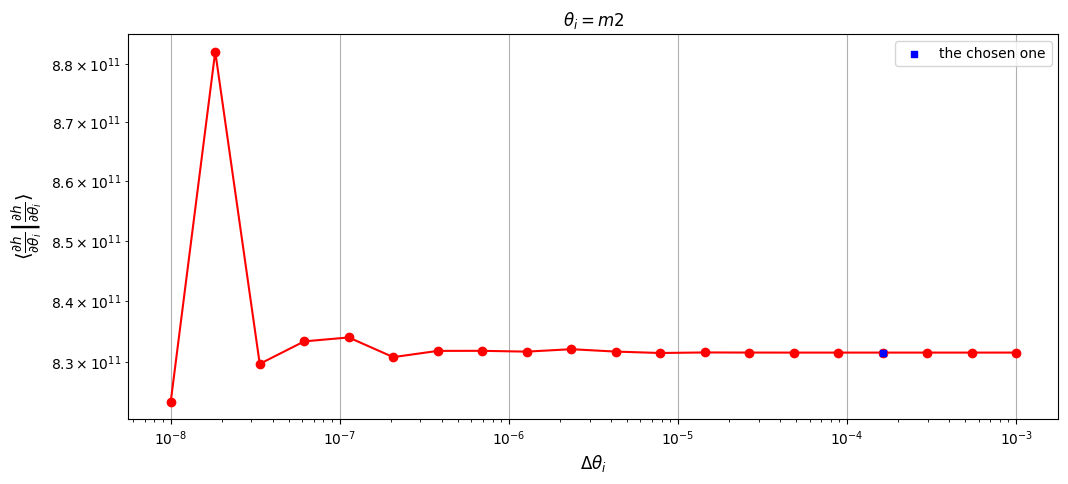

Gamma_ii for a: 52563539184071.39
Gamma_ii for a: 52563566489381.42
Gamma_ii for a: 52563604426384.91
Gamma_ii for a: 52563680787998.31
Gamma_ii for a: 52562979087122.6
Gamma_ii for a: 52563315079283.39
Gamma_ii for a: 52565880783995.94
Gamma_ii for a: 52562863755922.664
Gamma_ii for a: 52561308582272.87
Gamma_ii for a: 52568953643978.99
Gamma_ii for a: 52584786991039.195
Gamma_ii for a: 52564950730168.68
Gamma_ii for a: 52514446049037.1
Gamma_ii for a: 52607014303988.34
Gamma_ii for a: 52661062562952.305
Gamma_ii for a: 51985056559654.11
Gamma_ii for a: 52710551377780.914
Gamma_ii for a: 54146418635906.14
Gamma_ii for a: 52744435590772.98
Gamma_ii for a: 53857724888877.734
[np.float64(5.194721715994301e-07), np.float64(7.21735198686871e-07), np.float64(1.4527447899669421e-06), np.float64(1.3349716623707257e-05), np.float64(6.3921417490938655e-06), np.float64(4.8809316504937594e-05), np.float64(5.7398472185288524e-05), np.float64(2.958780311495863e-05), np.float64(0.0001454292158428881

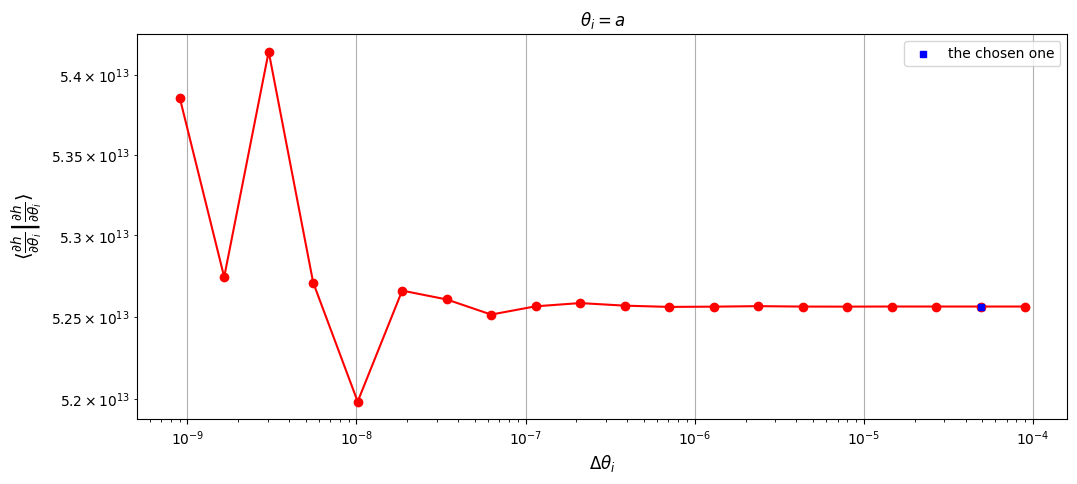

Gamma_ii for p0: 101867110568527.6
Gamma_ii for p0: 101867102549957.0
Gamma_ii for p0: 101867090229940.89
Gamma_ii for p0: 101866977647037.75
Gamma_ii for p0: 101867043824869.61
Gamma_ii for p0: 101867105407050.89
Gamma_ii for p0: 101867266956623.16
Gamma_ii for p0: 101867533831841.6
Gamma_ii for p0: 101867668296980.03
Gamma_ii for p0: 101866010334047.94
Gamma_ii for p0: 101869327556735.6
Gamma_ii for p0: 101858644381098.28
Gamma_ii for p0: 101868965200658.38
Gamma_ii for p0: 101873770036750.42
Gamma_ii for p0: 101851901764478.02
Gamma_ii for p0: 101819866961571.05
Gamma_ii for p0: 101927002878202.25
Gamma_ii for p0: 101882138594946.12
Gamma_ii for p0: 101607761080947.58
Gamma_ii for p0: 101114671992170.0
[np.float64(7.871599754020278e-08), np.float64(1.2094206363964528e-07), np.float64(1.1051952825253854e-06), np.float64(6.496490854603408e-07), np.float64(6.04534516173535e-07), np.float64(1.5858830524472165e-06), np.float64(2.6198260466189923e-06), np.float64(1.3199981965375598e-06), 

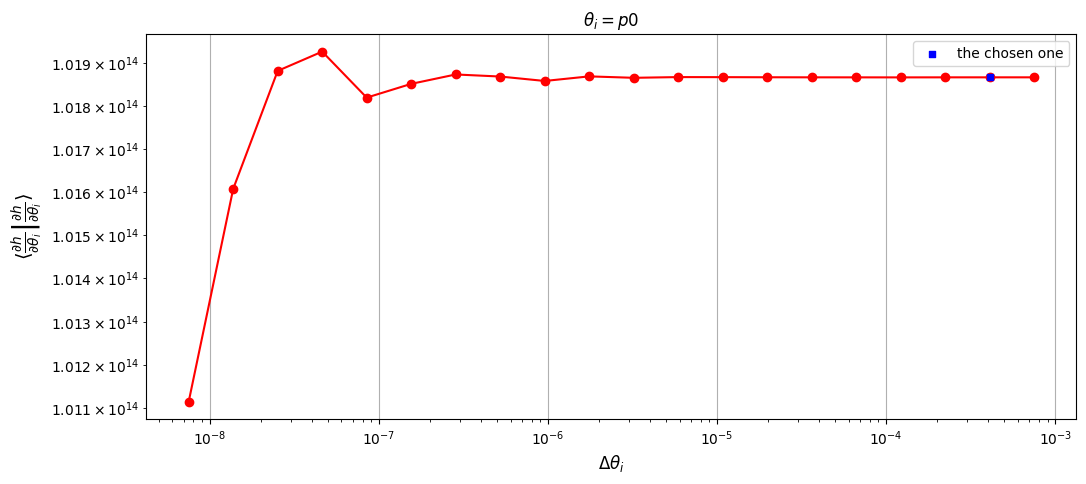

Gamma_ii for e0: 1561680649524043.8
Gamma_ii for e0: 1561680230185172.5
Gamma_ii for e0: 1561680721337142.5
Gamma_ii for e0: 1561676486164024.5
Gamma_ii for e0: 1561677496528676.0
Gamma_ii for e0: 1561674789247929.8
Gamma_ii for e0: 1561700643159808.8
Gamma_ii for e0: 1561734955599332.5
Gamma_ii for e0: 1561761136188221.5
Gamma_ii for e0: 1561807677837188.0
Gamma_ii for e0: 1561676065985165.8
Gamma_ii for e0: 1561710849433889.8
Gamma_ii for e0: 1562013937062429.2
Gamma_ii for e0: 1562790298974439.8
Gamma_ii for e0: 1561320492444151.0
Gamma_ii for e0: 1564381866003860.2
Gamma_ii for e0: 1572823136629493.8
Gamma_ii for e0: 1564635323490562.2
Gamma_ii for e0: 1563350383597867.2
Gamma_ii for e0: 1521760387397684.5
[np.float64(2.6851775616079733e-07), np.float64(3.145021663451578e-07), np.float64(2.7119401204553807e-06), np.float64(6.469739454822498e-07), np.float64(1.733575239153198e-06), np.float64(1.65549729343067e-05), np.float64(2.1970718783445705e-05), np.float64(1.6763503894647273e-0

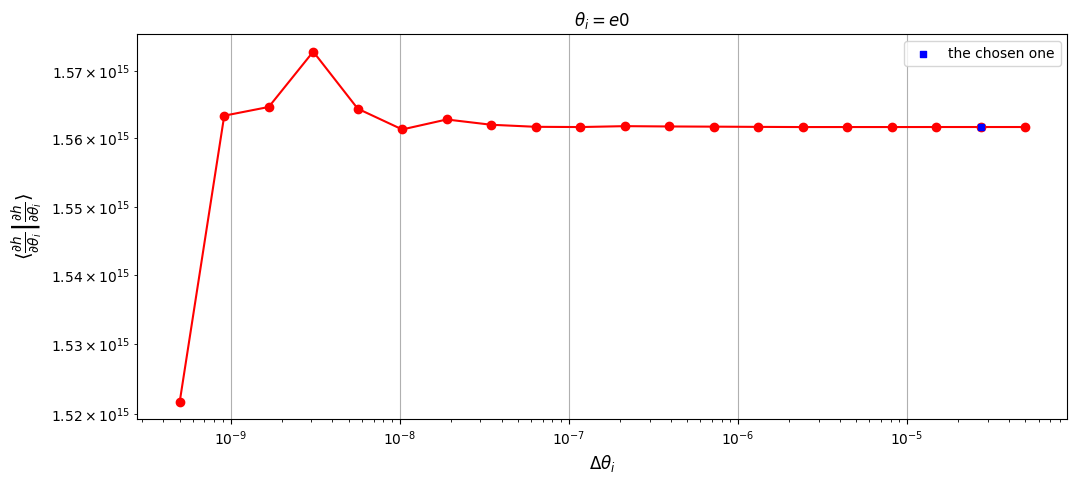

Gamma_ii for qS: 163255.34517168647
Gamma_ii for qS: 181011.4408707505
Gamma_ii for qS: 180723.81386608013
Gamma_ii for qS: 181188.54692919314
Gamma_ii for qS: 181320.70924689726
Gamma_ii for qS: 180796.51027366798
Gamma_ii for qS: 180905.8786963288
Gamma_ii for qS: 180388.9308840734
Gamma_ii for qS: 181239.94082295688
Gamma_ii for qS: 187238.90315706332
Gamma_ii for qS: 186617.4546699576
Gamma_ii for qS: 180961.0724437908
Gamma_ii for qS: 180765.07226826018
Gamma_ii for qS: 180667.1943150897
Gamma_ii for qS: 180761.84316975815
Gamma_ii for qS: 180559.93448318174
Gamma_ii for qS: 180536.78757145823
Gamma_ii for qS: 179970.25474966664
Gamma_ii for qS: 179954.78440253634
Gamma_ii for qS: 179942.60975834102
[np.float64(0.09809377580582102), np.float64(0.001591527970317707), np.float64(0.002564914123929787), np.float64(0.000728887054617452), np.float64(0.0028993865668966844), np.float64(0.0006045598045179584), np.float64(0.0028657402076826995), np.float64(0.00469548784345931), np.float64(0

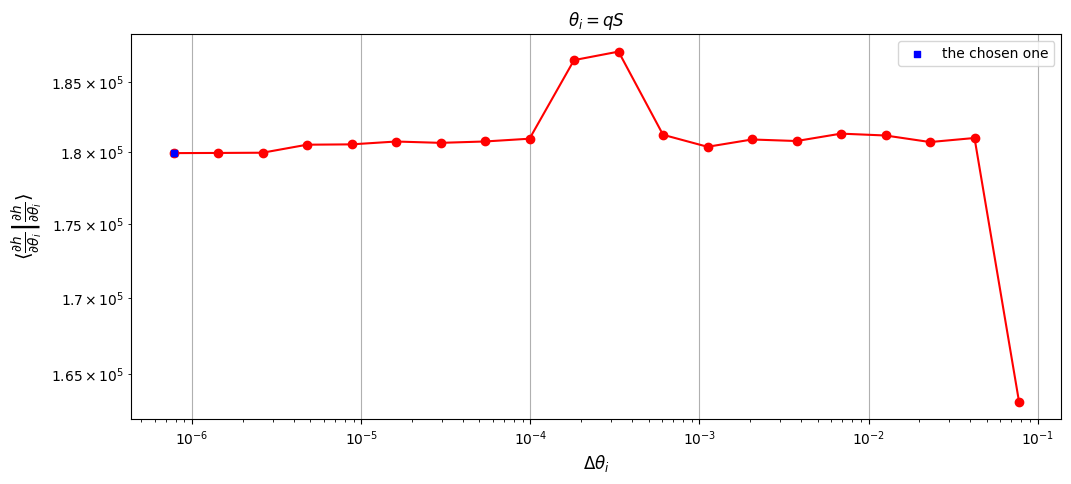

Gamma_ii for phiS: 244111.70335458533
Gamma_ii for phiS: 308277.0382183692
Gamma_ii for phiS: 310849.8533907205
Gamma_ii for phiS: 310873.80396849994
Gamma_ii for phiS: 310812.60193049285
Gamma_ii for phiS: 310860.05492483475
Gamma_ii for phiS: 310770.02177361585
Gamma_ii for phiS: 310779.6498973921
Gamma_ii for phiS: 310768.7935104474
Gamma_ii for phiS: 310798.7016348236
Gamma_ii for phiS: 310784.08772902295
Gamma_ii for phiS: 310787.3299849179
Gamma_ii for phiS: 310751.59445385635
Gamma_ii for phiS: 310685.427869785
Gamma_ii for phiS: 310588.8102940499
Gamma_ii for phiS: 311089.19541513396
Gamma_ii for phiS: 310470.2134659007
Gamma_ii for phiS: 309973.70501584
Gamma_ii for phiS: 308664.14717393793
Gamma_ii for phiS: 308566.0221345716
[np.float64(0.20814179101569055), np.float64(0.008276713481725317), np.float64(7.704276614399797e-05), np.float64(0.00019690977015396726), np.float64(0.00015265066575819095), np.float64(0.00028970989770849324), np.float64(3.098054772701284e-05), np.float

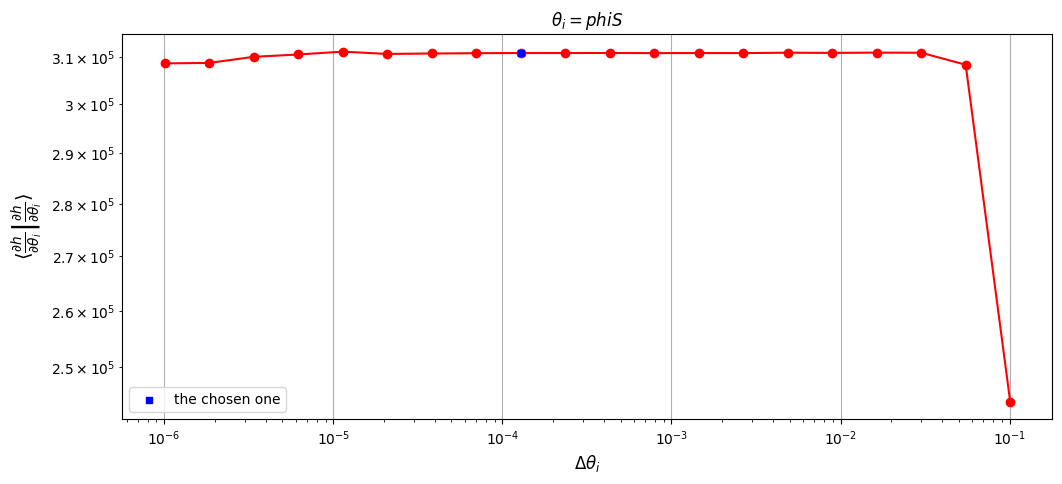

Gamma_ii for dev_1: 4663.453628031772
Gamma_ii for dev_1: 4663.710146907114
Gamma_ii for dev_1: 4667.199811051856
Gamma_ii for dev_1: 4664.885586259626
Gamma_ii for dev_1: 4667.6256363393695
Gamma_ii for dev_1: 4659.381885327083
Gamma_ii for dev_1: 4687.485057278381
Gamma_ii for dev_1: 4654.290184895751
Gamma_ii for dev_1: 4654.756262035654
Gamma_ii for dev_1: 4756.454824246592
Gamma_ii for dev_1: 4573.0310100570905
Gamma_ii for dev_1: 5442.008076465953
Gamma_ii for dev_1: 5030.966541441088
Gamma_ii for dev_1: 5179.093052369214
Gamma_ii for dev_1: 3044.598559827583
Gamma_ii for dev_1: 7639.443881973167
Gamma_ii for dev_1: 31695.855360669062
Gamma_ii for dev_1: 4826.0842588767955
Gamma_ii for dev_1: 246696.8605654198
Gamma_ii for dev_1: 104153.83600632501
[np.float64(5.500317714052763e-05), np.float64(0.0007476997527465386), np.float64(0.0004960946521490447), np.float64(0.0005870329570588343), np.float64(0.0017692799635605821), np.float64(0.005995362461510363), np.float64(0.007132102009

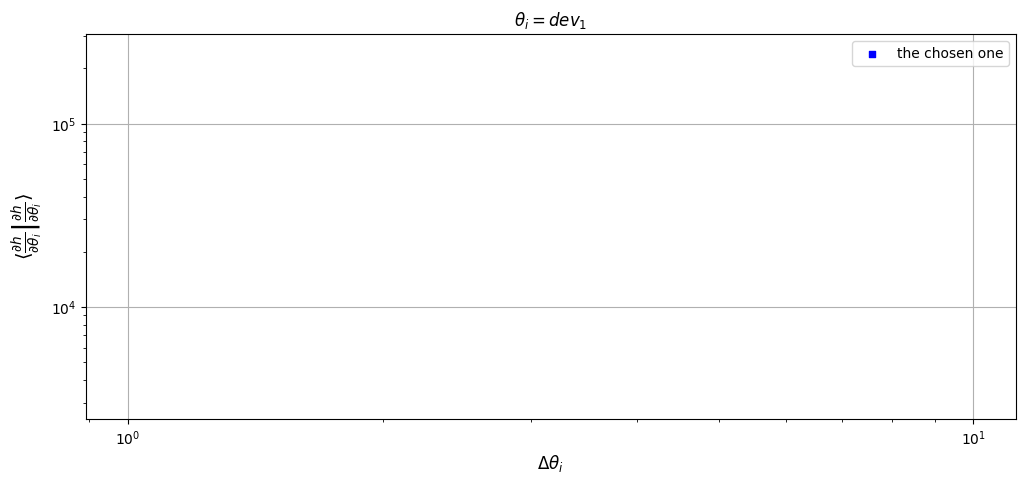

Gamma_ii for dev_2: 5908.485242283395
Gamma_ii for dev_2: 107.88954958321473
Gamma_ii for dev_2: 3638.823776870271
Gamma_ii for dev_2: 14627.791117228178
Gamma_ii for dev_2: 10247.747771856426
Gamma_ii for dev_2: 69644.05072320027
Gamma_ii for dev_2: 472672.3024394536
Gamma_ii for dev_2: 75100.2561274291
Gamma_ii for dev_2: 15529880.029828534
Gamma_ii for dev_2: 36999952.66082013
Gamma_ii for dev_2: 154885261.326902
Gamma_ii for dev_2: 24208918.5890358
Gamma_ii for dev_2: 660502850.5784153
Gamma_ii for dev_2: 4146820707.806125
Gamma_ii for dev_2: 21130415424.309704
Gamma_ii for dev_2: 46975481060.24373
Gamma_ii for dev_2: 1961575649.943758
Gamma_ii for dev_2: 87528919223.92906
Gamma_ii for dev_2: 2326384289149.478
Gamma_ii for dev_2: 251529044498.57162
[np.float64(53.76420343868621), np.float64(0.9703504329423697), np.float64(0.7512390115699306), np.float64(0.4274152177516258), np.float64(0.8528553743580192), np.float64(0.8526589132391119), np.float64(5.293884026672687), np.float64(0.9

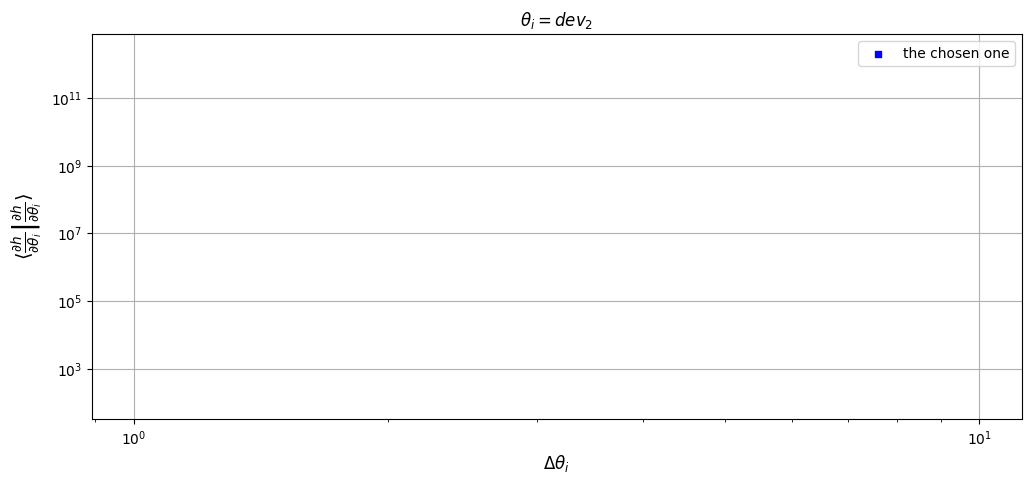

stable deltas: {'m1': 29.775122519890985, 'm2': 0.00016241512734430089, 'a': 4.911431572924056e-05, 'p0': 0.000409081371783237, 'e0': 2.7275105141762642e-05, 'qS': 7.756752445526642e-07, 'phiS': 0.00012843818575432182, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': -0.03590868480960891, 'dev_2': -1.1260175198691632e-06}
Time taken to compute stable deltas is 62.86193299293518 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.6376161575317383 seconds


In [8]:
x_best_fit_0PA_dev =[1000390.0111866979, 10.002306562504852, 0.9002559335743208, 7.49838263639546, 0.49994741610777566, 0.7756752445526642, 1.0079314684455698, 0.9262021678310152, 0.5305190074473904, -0.6581992660737483, -0.00012710912431291273]

add_kwargs_0PA_dev = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': x_best_fit_0PA_dev[9], 'dev_2': x_best_fit_0PA_dev[10]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA_dev_local  = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 8, Ndelta = 20,return_derivatives = False)



In [9]:
np.save("emri_results_corrected/Fisher_0PA_dev.npy", Fisher_0PA_dev)

In [10]:
def fishinv(M, Fisher, index_of_M=0):
    J = np.eye(len(Fisher))
    J[index_of_M, index_of_M] = M

    Fisher_lnM = J.T @ Fisher @ J
    print('Condition number of Fisher_lnM: ', np.linalg.cond(Fisher_lnM))
    Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)  # Jacobian for Covariance = partial new/partial old, going from lnM -> M
    Fisher_inv = J.T @ Fisher_lnM_inv @ J
    return Fisher_inv

def fishinv_for_dev(M, Fisher, index_of_M=0, scale_factor_1=1, scale_factor_2=1,index_of_dev_1=9, index_of_dev_2=10):
    J = np.eye(len(Fisher))
    J[index_of_M, index_of_M] = M
    J[index_of_dev_1, index_of_dev_1] = scale_factor_1
    J[index_of_dev_2, index_of_dev_2] = scale_factor_2

    Fisher_lnM = J.T @ Fisher @ J
    print('Condition number of Fisher_lnM: ', np.linalg.cond(Fisher_lnM))
    Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)  # Jacobian for Covariance = partial new/partial old, going from lnM -> M
    Fisher_inv = J.T @ Fisher_lnM_inv @ J
    return Fisher_inv

In [11]:
Covariance_fit_1PA = fishinv(m1, Fisher_1PA, index_of_M=0)
Covariance_fit_0PA = fishinv(m1, Fisher_0PA, index_of_M=0)
Covariance_fit_0PA_dev = fishinv_for_dev(m1, Fisher_0PA_dev, index_of_M=0, scale_factor_1=1e6, scale_factor_2=1,index_of_dev_1=9, index_of_dev_2=10)
Covariance_fit_0PA_dev_local = fishinv_for_dev(m1, Fisher_0PA_dev_local, index_of_M=0, scale_factor_1=1e6, scale_factor_2=1,index_of_dev_1=9, index_of_dev_2=10)

Condition number of Fisher_lnM:  112298474389581.05
Condition number of Fisher_lnM:  110714963827429.92
Condition number of Fisher_lnM:  264305382190901.2
Condition number of Fisher_lnM:  237017581905986.06


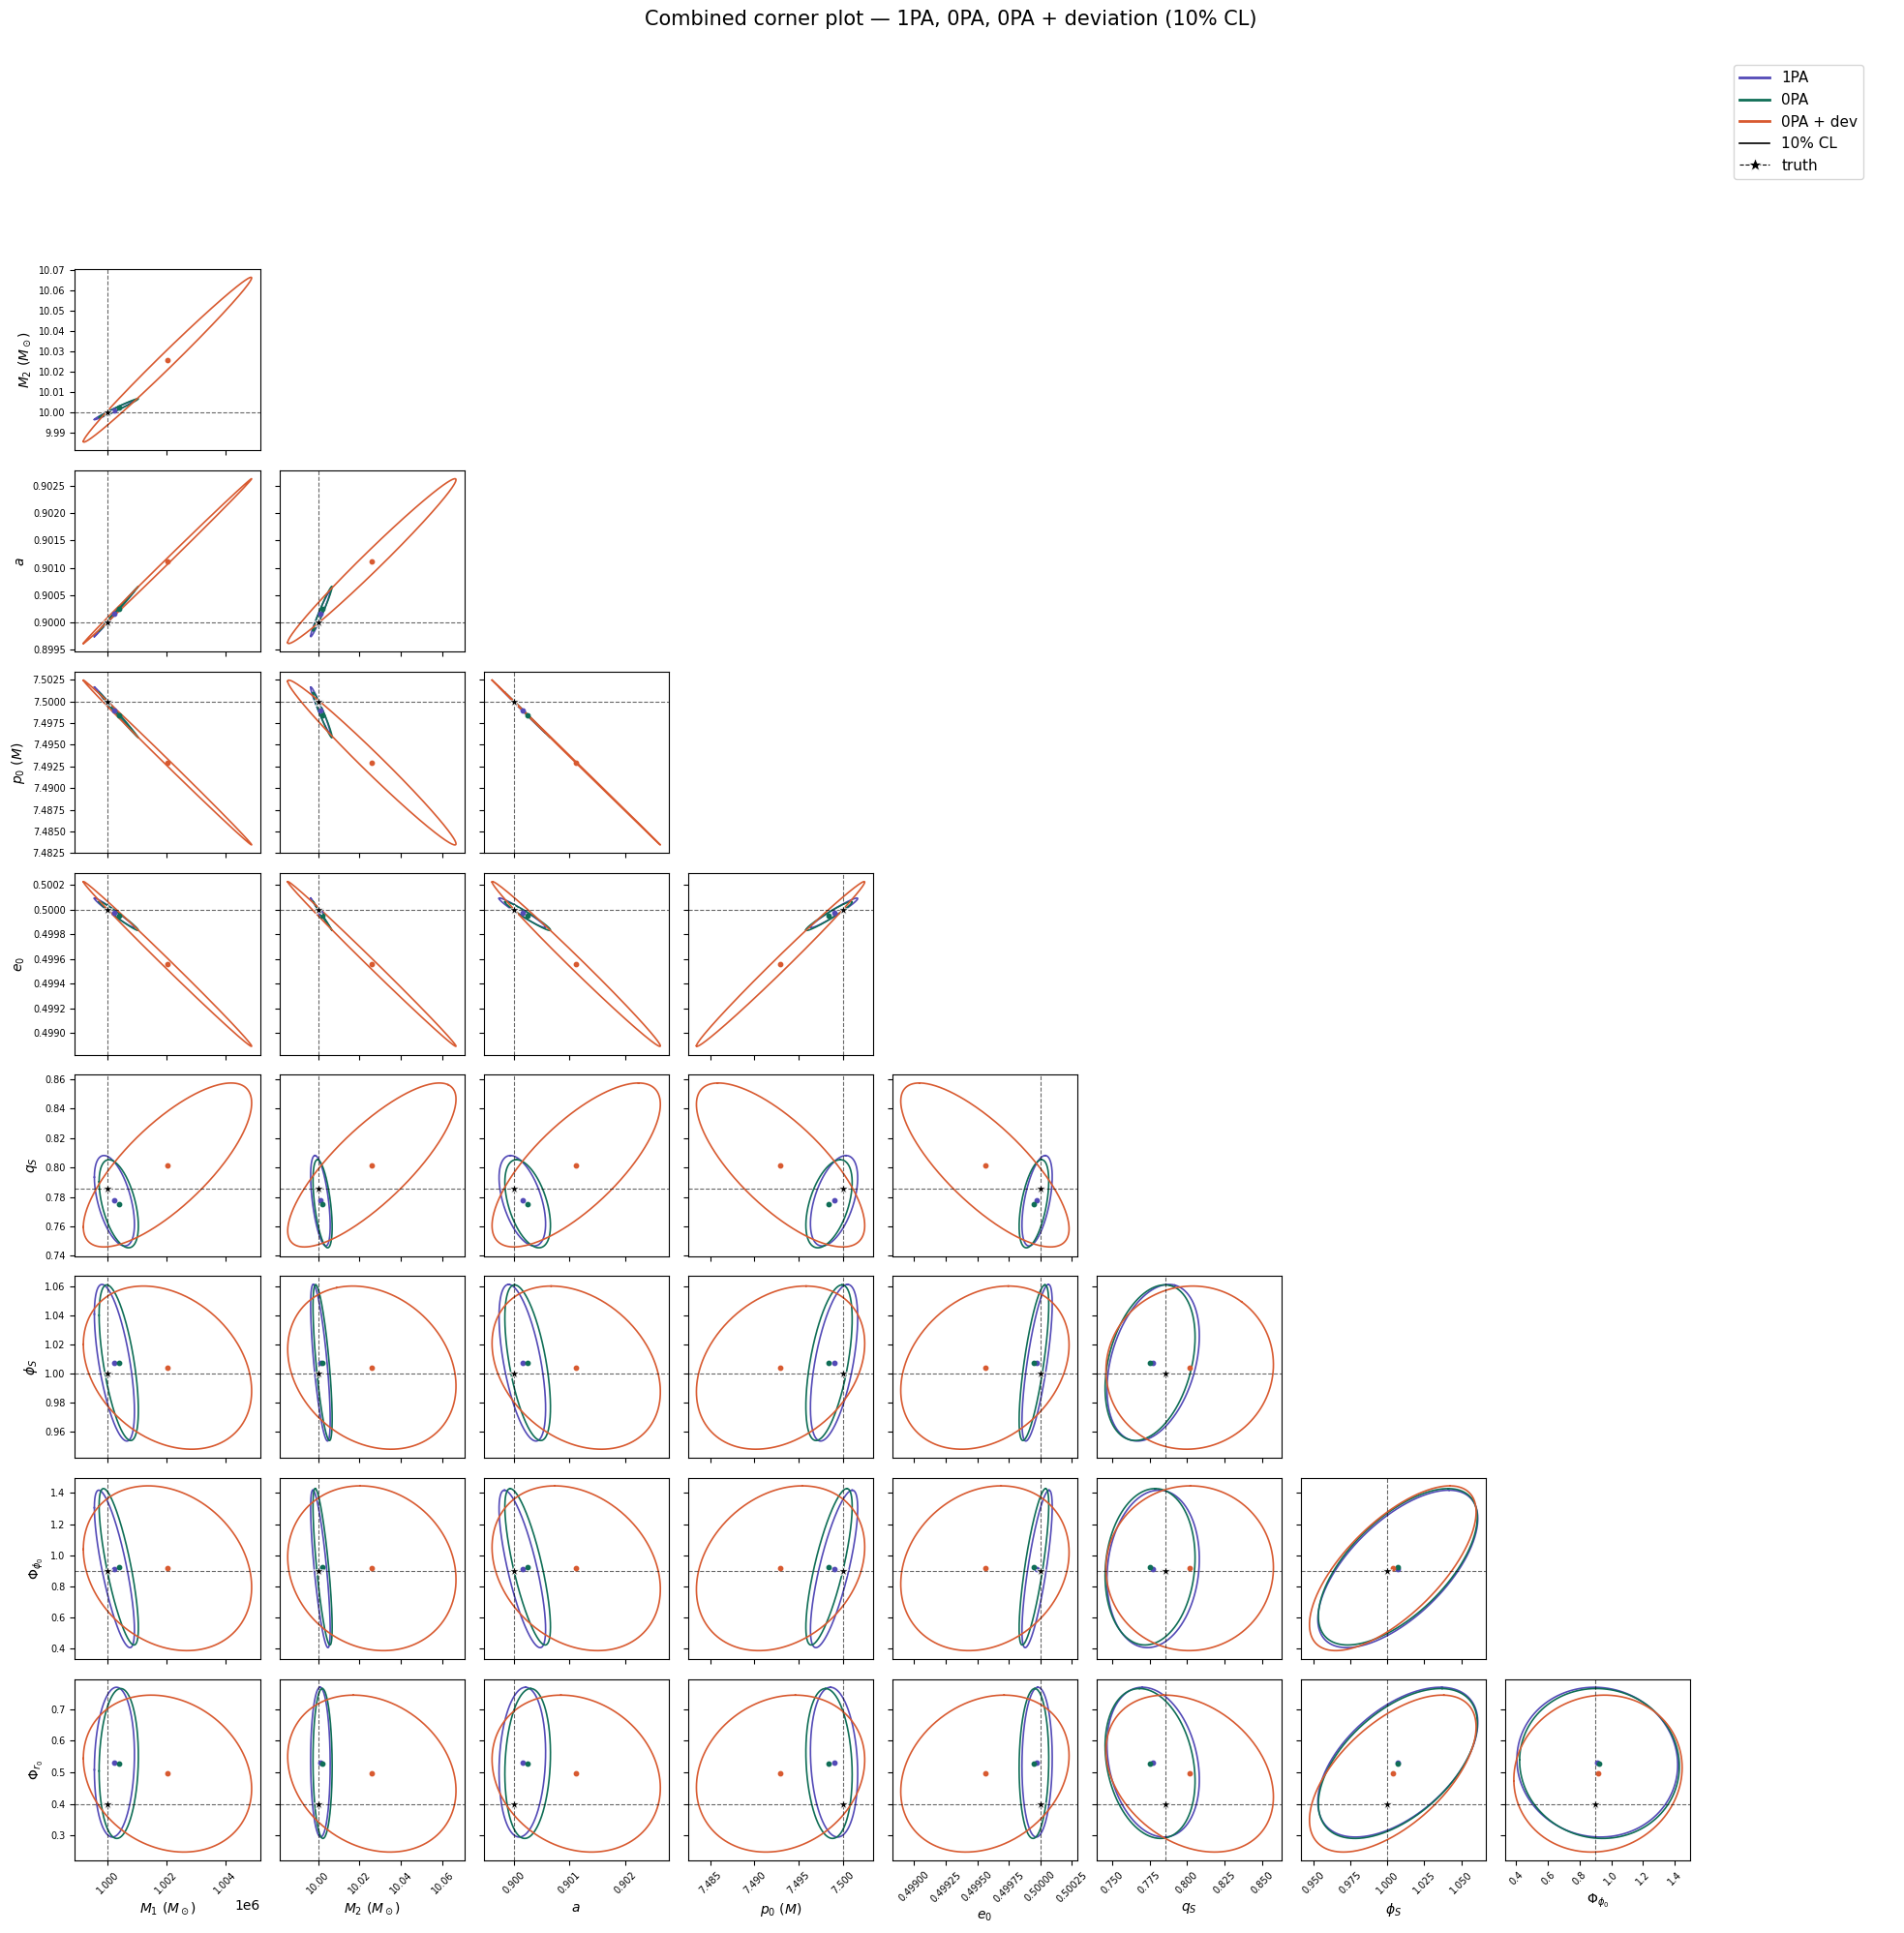

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
x_best_fit_1PA = np.array([1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502])

x_best_fit_0PA = np.array([1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, 0.7753479239641903, 1.0071736406662928, 0.9247980336593397, 0.527676177865538])

x_best_fit_0PA_dev = np.array([1002038.3206946955, 10.025942269951084, 0.9011207263816821, 7.492941363053822, 0.499560753899444, 0.8016696937534229, 1.00378495940247, 0.9154248514732031, 0.4958258737144708, -92.01945190544691, -0.00016624654748756643])

# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 2.5,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA,     '#534AB7', 9),
    ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA,     '#0F6E56', 9),
    ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev, '#D85A30', 11),
]

LEVELS         = (0.99,)
LEVEL_STYLES   = {0.99: '-'}
N_PARAMS_TOTAL = 9
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D} to match labels.")

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name)
                      for name, _, _, color, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='10% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + deviation (10% CL)',
                 fontsize=15, y=1.005)
    plt.tight_layout()
    plt.show()


combined_triangle_plot()

In [17]:
def mahalanobis_distances():
    print("Mahalanobis distances from truth (9 shared parameters):\n")
    truth9 = true_params  # already length 9

    fit_list = [
        ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA),
        ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA),
        ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev),
    ]

    for name, mean, cov in fit_list:
        mean9 = mean[:9]
        cov9  = cov[:9, :9]
        delta = mean9 - truth9
        cov9_inv = np.linalg.inv(cov9)
        d2 = delta @ cov9_inv @ delta
        d  = np.sqrt(d2)
        print(f"  {name:12s}  D² = {d2:.4f}   D = {d:.4f}")

mahalanobis_distances()

Mahalanobis distances from truth (9 shared parameters):

  1PA           D² = 14.2003   D = 3.7683
  0PA           D² = 6240.7730   D = 78.9986
  0PA + dev     D² = 123.2449   D = 11.1016


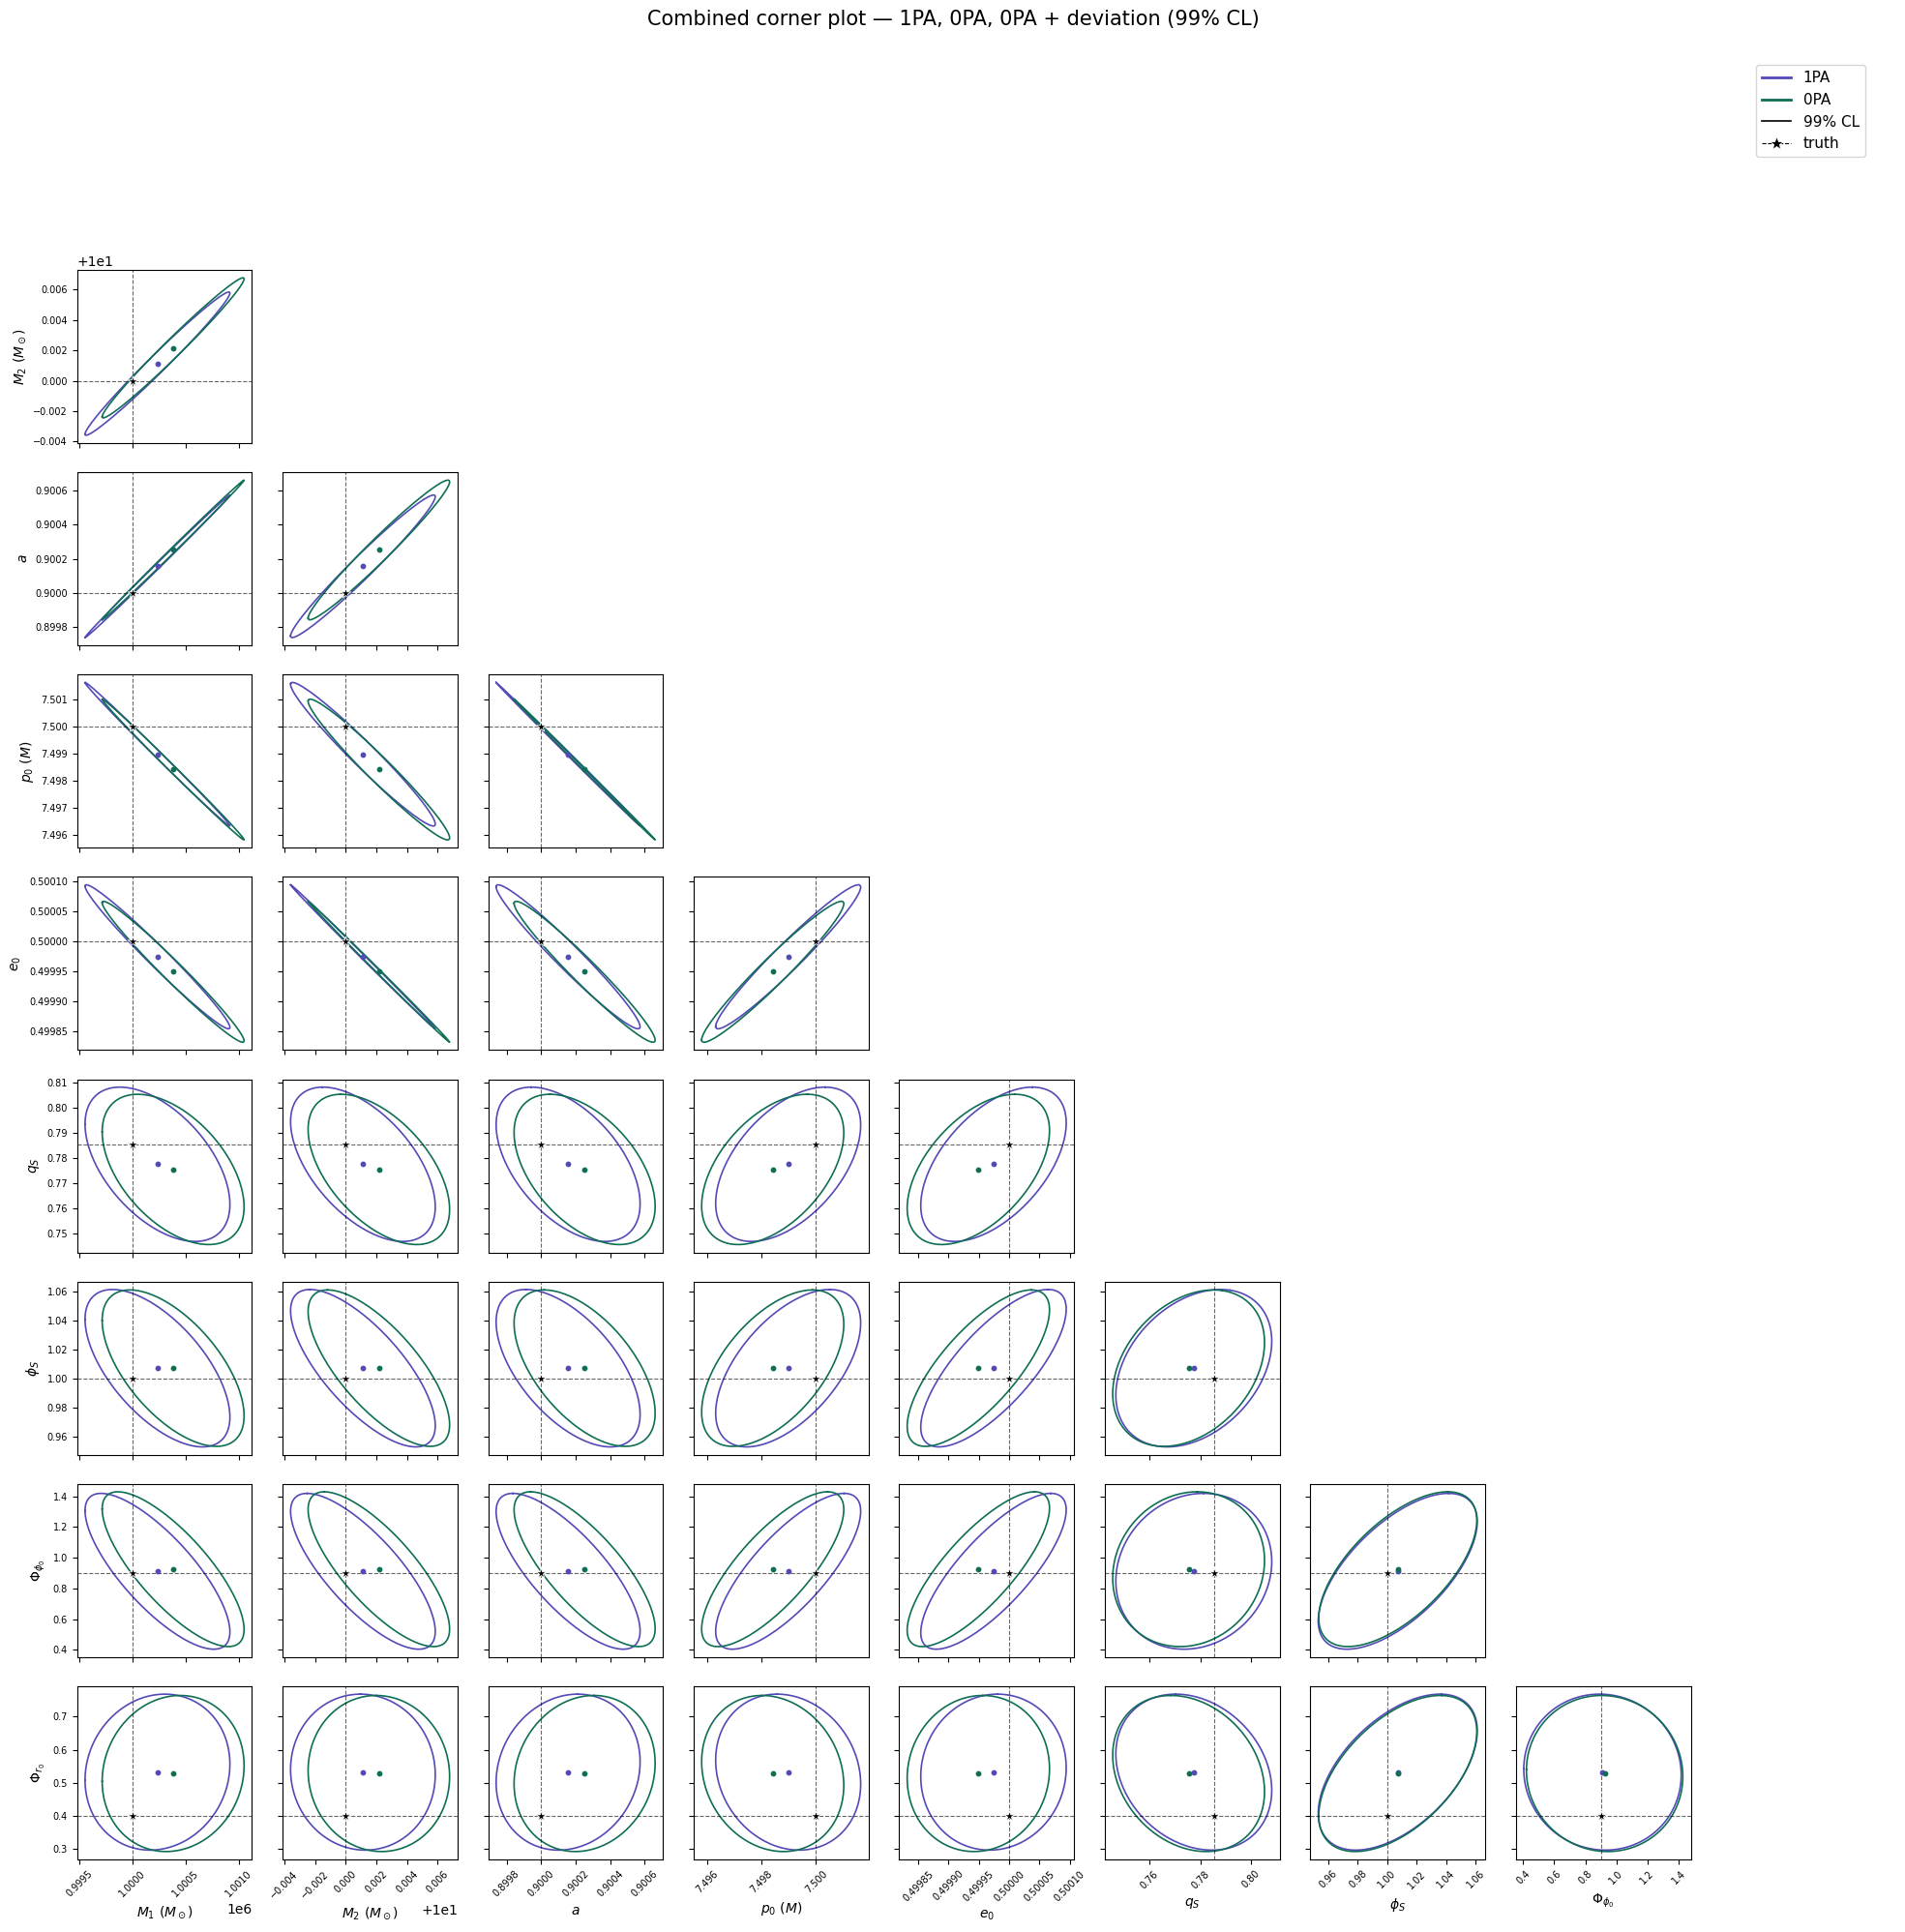

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
x_best_fit_1PA = np.array([1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502])

x_best_fit_0PA = np.array([1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, 0.7753479239641903, 1.0071736406662928, 0.9247980336593397, 0.527676177865538])

#x_best_fit_0PA_dev = np.array([1002038.3206946955, 10.025942269951084, 0.9011207263816821, 7.492941363053822, 0.499560753899444, 0.8016696937534229, 1.00378495940247, 0.9154248514732031, 0.4958258737144708, -92.01945190544691, -0.00016624654748756643])

# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 2.5,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA,     '#534AB7', 9),
    ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA,     '#0F6E56', 9),
   # ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev, '#D85A30', 9),
]

LEVELS         = (0.99,)
LEVEL_STYLES   = {0.99: '-'}
N_PARAMS_TOTAL = 9
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D} to match labels.")

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name)
                      for name, _, _, color, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='99% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + deviation (99% CL)',
                 fontsize=15, y=1.005)
    plt.tight_layout()
    plt.show()


combined_triangle_plot()

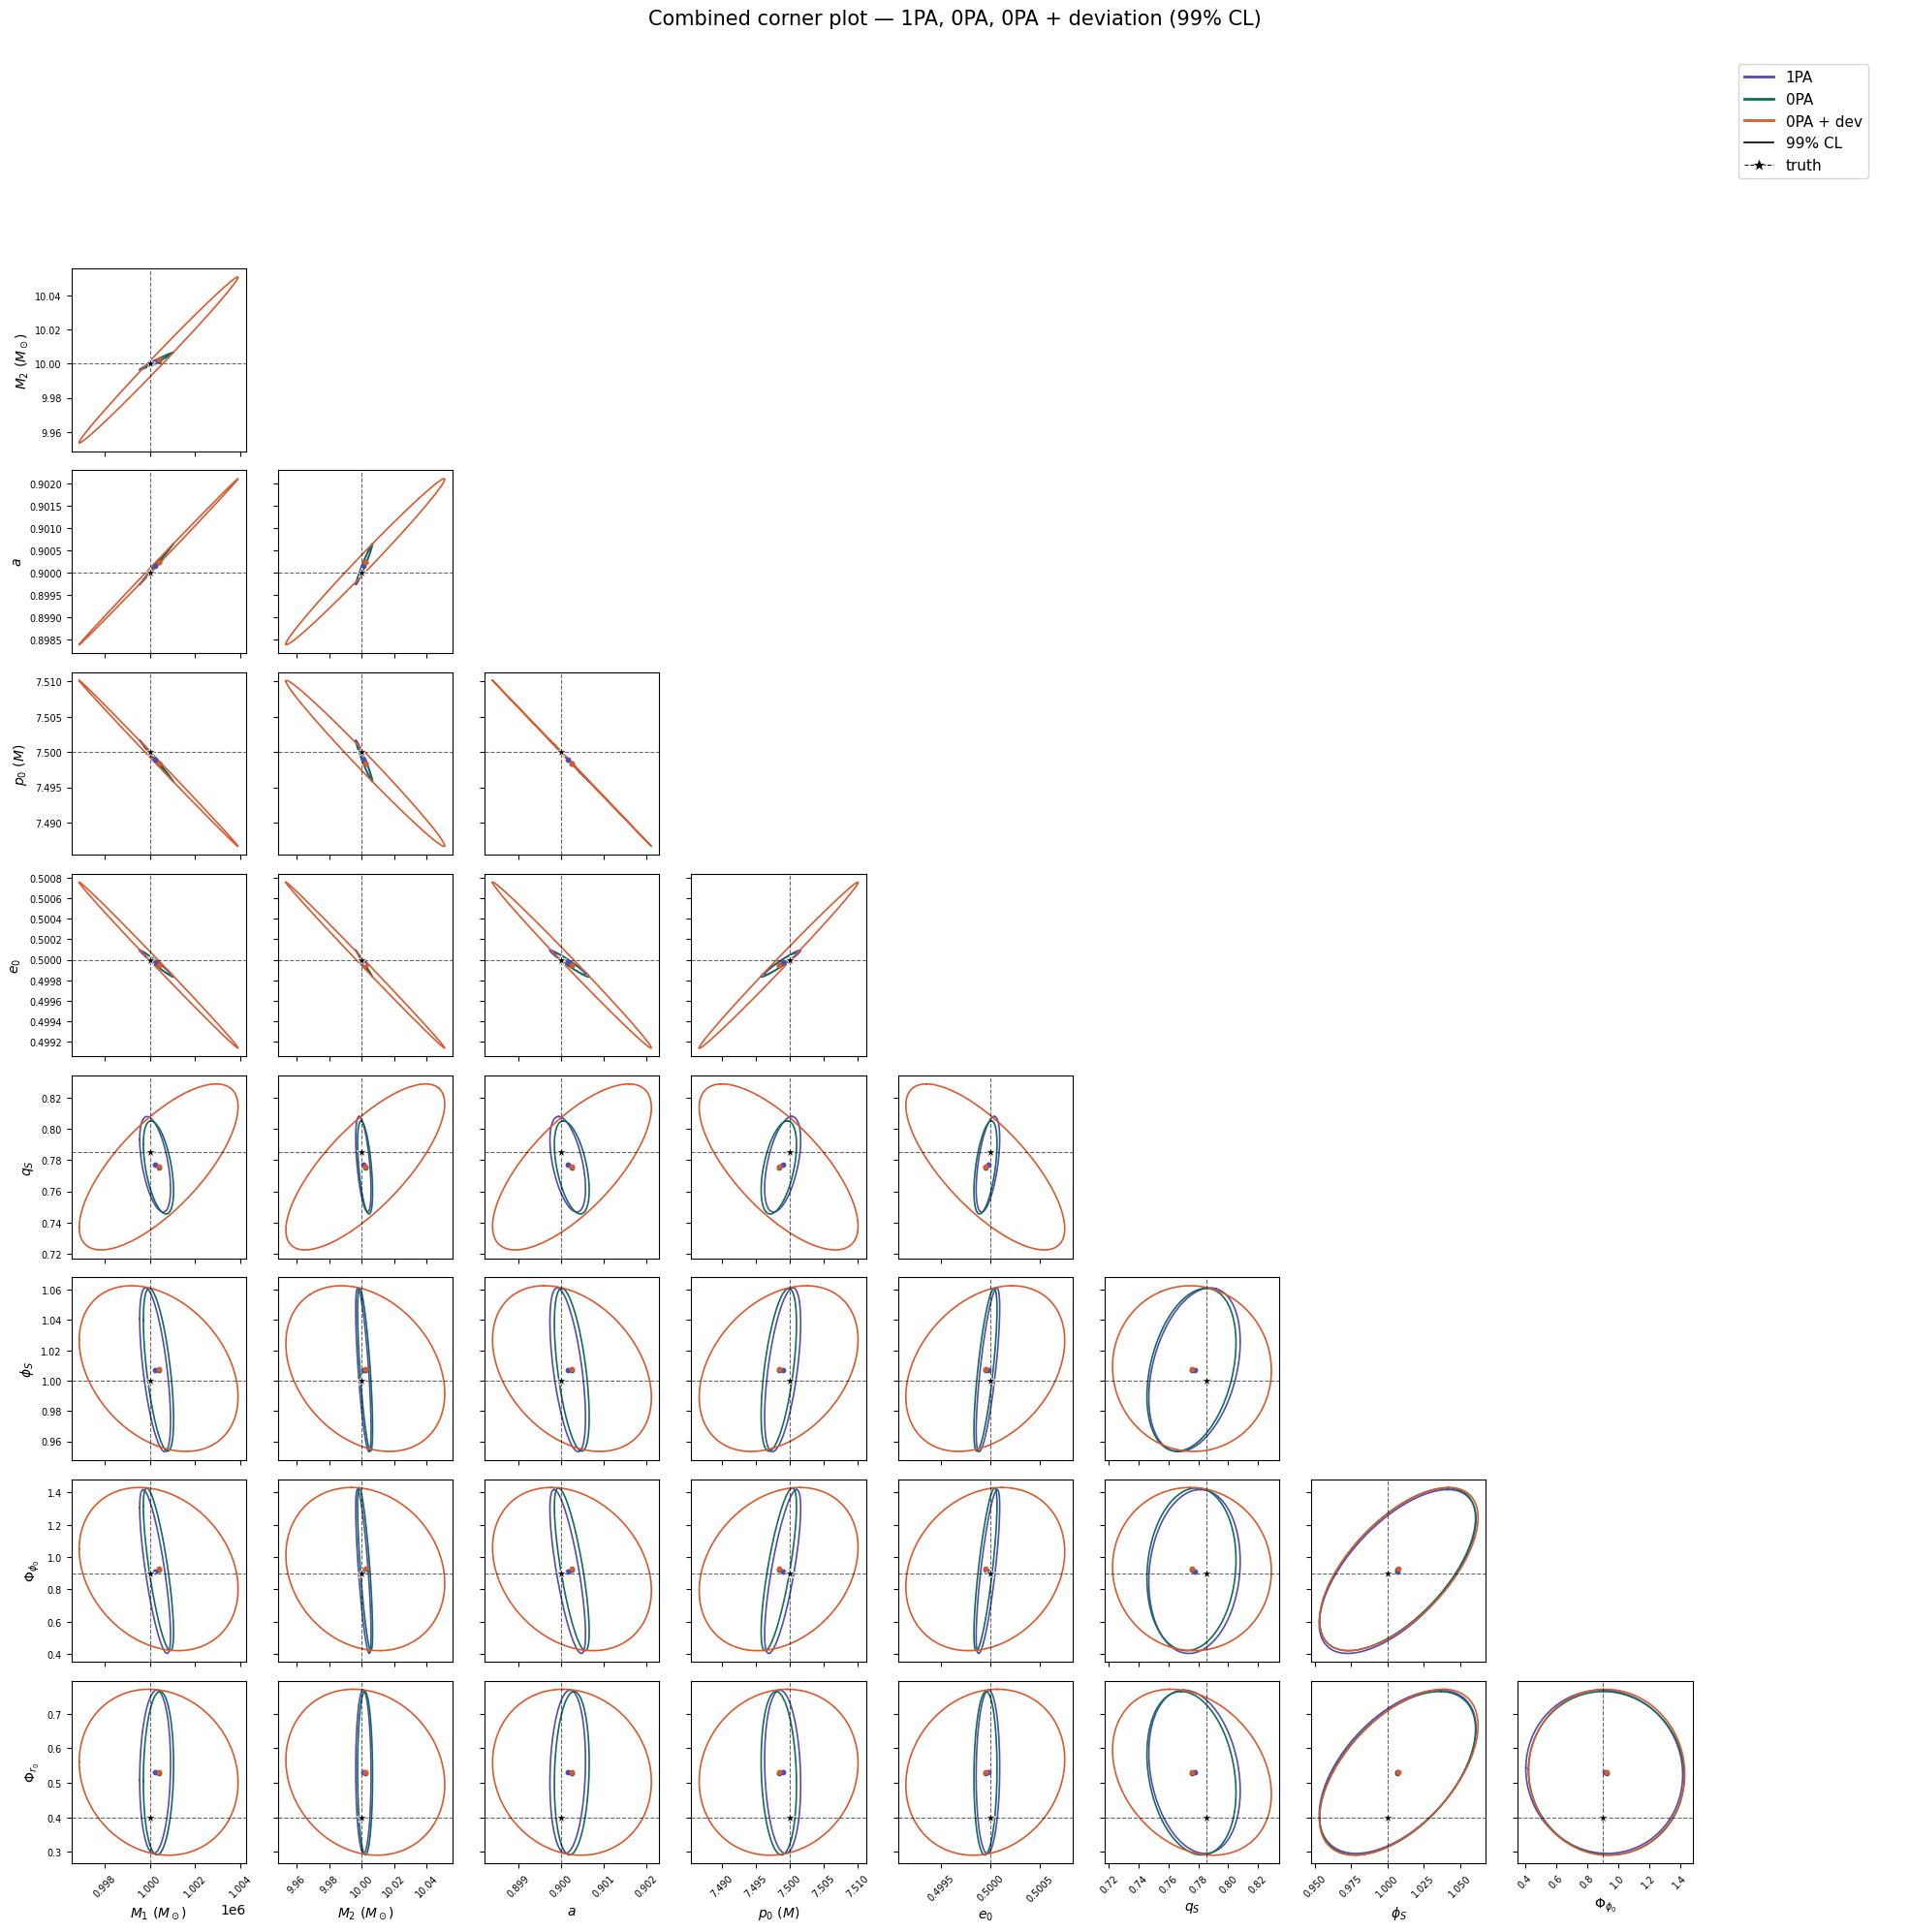

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
x_best_fit_1PA = np.array([1000234.5396107387, 10.00112889617945, 0.9001561805718662, 7.498977936821298, 0.49997431515945046, 0.7773862440642697, 1.0071592783261298, 0.911151948599342, 0.5318777296989502])

x_best_fit_0PA = np.array([1000381.7041232118, 10.002168695473182, 0.9002516907947907, 7.498409716347528, 0.49994934399028595, 0.7753479239641903, 1.0071736406662928, 0.9247980336593397, 0.527676177865538])

x_best_fit_0PA_dev = np.array([1000390.0111866979, 10.002306562504852, 0.9002559335743208, 7.49838263639546, 0.49994741610777566, 0.7756752445526642, 1.0079314684455698, 0.9262021678310152, 0.5305190074473904, -0.6581992660737483, -0.00012710912431291273]
)

# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 2.5,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
fits = [
    ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA,     '#534AB7', 9),
    ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA,     '#0F6E56', 9),
   ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev_local, '#D85A30', 9),
]

LEVELS         = (0.99,)
LEVEL_STYLES   = {0.99: '-'}
N_PARAMS_TOTAL = 9
TRUTH_COLOR    = '#000000'


# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]

    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])


# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS_TOTAL
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))

    if len(true_params) != D:
        raise ValueError(
            f"true_params has {len(true_params)} entries; expected {D} to match labels.")

    for i in range(D):
        for j in range(D):
            ax = axes[i, j]

            if j >= i:
                ax.axis('off')
                continue

            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)

            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)

            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])

            ax.tick_params(labelsize=7)

    legend_handles = [plt.Line2D([0], [0], color=color, lw=2, label=name)
                      for name, _, _, color, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='99% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))

    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)

    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + deviation (99% CL)',
                 fontsize=15, y=1.005)
    plt.tight_layout()
    plt.show()


combined_triangle_plot()

In [19]:
def mahalanobis_distances():
    print("Mahalanobis distances from truth (9 shared parameters):\n")
    truth9 = true_params  # already length 9

    fit_list = [
        ('1PA',       x_best_fit_1PA,     Covariance_fit_1PA),
        ('0PA',       x_best_fit_0PA,     Covariance_fit_0PA),
        ('0PA + dev', x_best_fit_0PA_dev, Covariance_fit_0PA_dev_local),
    ]

    for name, mean, cov in fit_list:
        mean9 = mean[:9]
        cov9  = cov[:9, :9]
        delta = mean9 - truth9
        cov9_inv = np.linalg.inv(cov9)
        d2 = delta @ cov9_inv @ delta
        d  = np.sqrt(d2)
        print(f"  {name:12s}  D² = {d2:.4f}   D = {d:.4f}")

mahalanobis_distances()

Mahalanobis distances from truth (9 shared parameters):

  1PA           D² = 14.2003   D = 3.7683
  0PA           D² = 6240.7730   D = 78.9986
  0PA + dev     D² = 27.8987   D = 5.2819


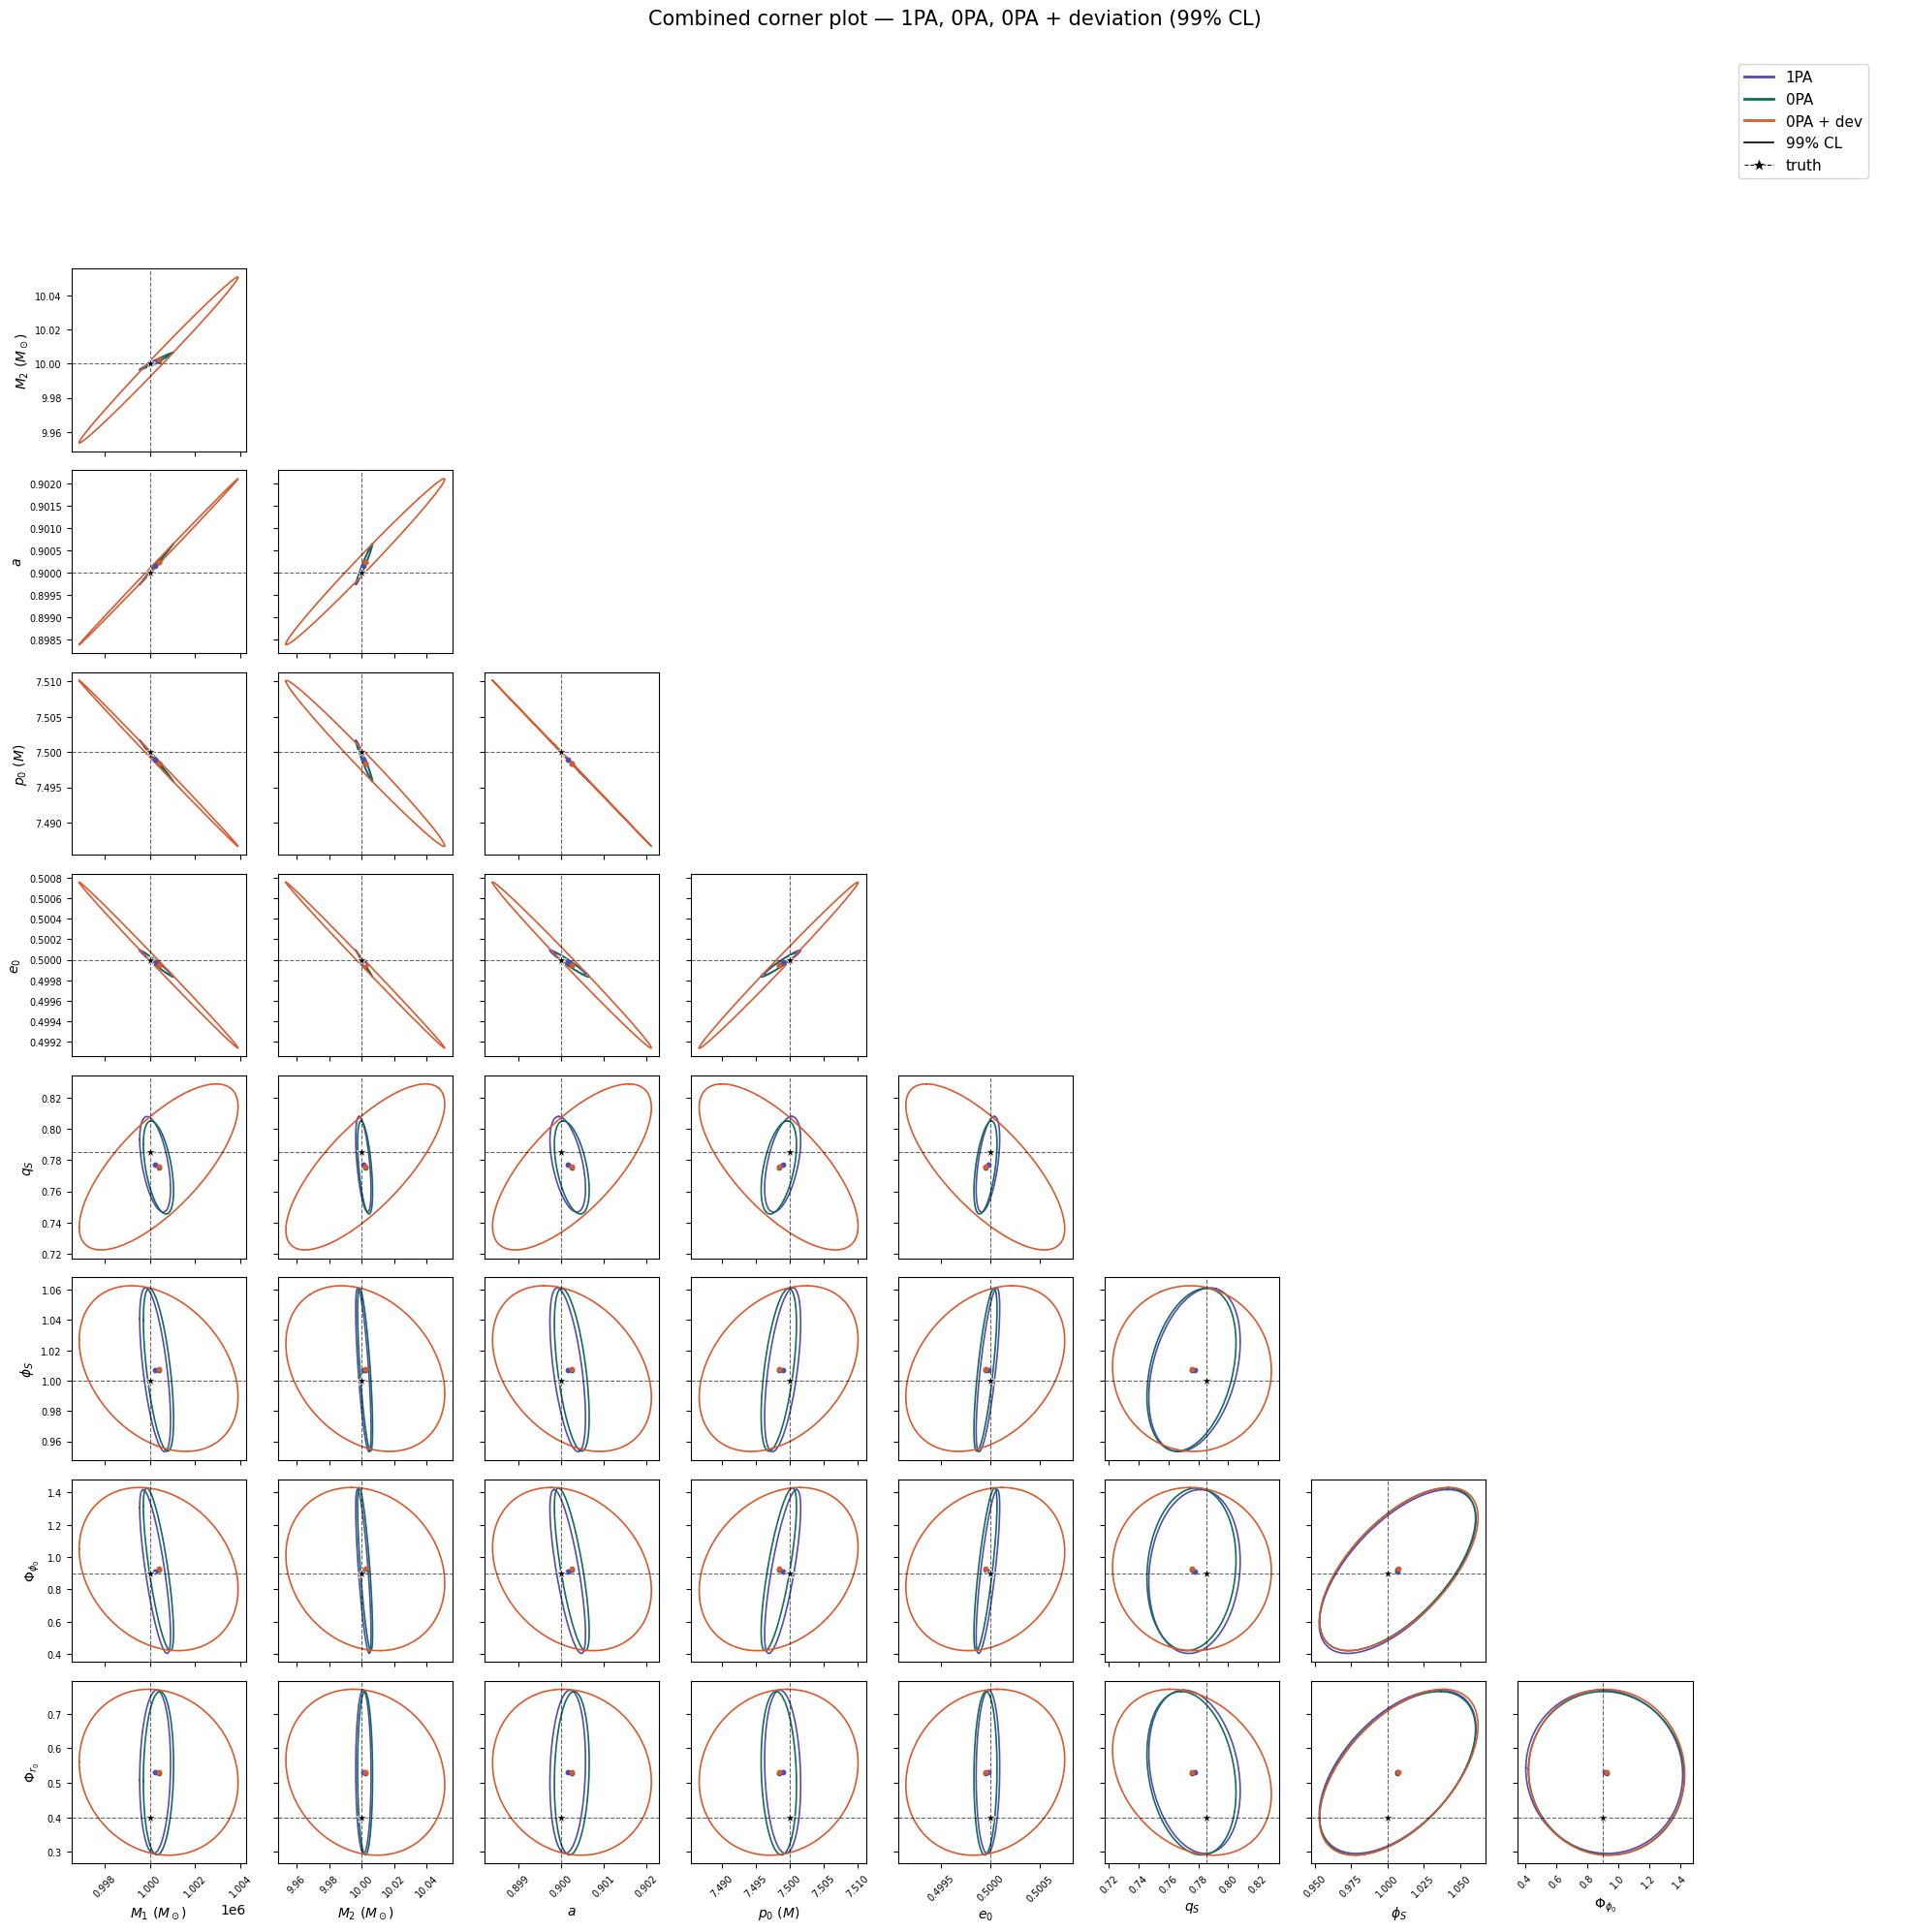